# Experimentos con Covariables v4 Cloud (Vertex AI)

**Tesis MEC** — 25 DGPs con covariables x T in {25,50,100,200} x R=500
**Horizonte por T:** T=25->H=6 * T=50->H=18 * T=100,200->H=24
**Metricas (univariado):** Bias, Varianza, RMSE, MAE, CRPS, Cobertura/Amplitud/Winkler 80%-95%
**Metricas (multivariado):** mismas per-variable + Trace MSFE y avgCRPS conjuntos (donde el engine las expone)
**Bloques h:** Corto h=1-6 * Medio h=7-18 * Largo h=19-24
**Logging:** dual stdout + `results/covariate_vertexai/run_YYYYMMDD_HHMMSS.log`
**Resultados:** `results/covariate_vertexai/` — si existen se cargan sin re-simular

**Bloques de experimentos:**
- **C-A** (5) — ARIMAX(1) univariado: variacion de fuerza (beta) y persistencia de X (rho_x)
- **C-B** (2) — ARIMAX con dinamica AR mas rica (alta persistencia / signo negativo)
- **C-C** (3) — ARIMAX con multiples covariables (asimetricas / balanceadas / con ruido)
- **C-D** (3) — ARIMAX-GARCH: efecto en media y/o en varianza
- **C-E** (3) — VARX bivariado: sistema multivariado con covariable exogena comun
- **C-F** (2) — ADL-ECM: cointegracion entre Y_t y X_t (I(1) con relacion de largo plazo)
- **C-G** (3) — ARIMAX con tendencia deterministica lineal (delta*t)
- **C-H** (4) — SARIMAX estacional con covariable (s=4 trimestral y s=12 mensual)

**Notas metodologicas:**
- En todos los experimentos las covariables son *completamente observadas*: se proveen historico (`X_train`) y futuro conocido (`X_future`) a los modelos que las aceptan.
- Chronos-2 recibe las covariables via la API de `past_covariates` / `future_covariates`.
- Los modelos clasicos (SARIMAX, VARMAX, ARDL-ECM) son el contraste correctamente especificado para cada DGP.
- C-H.3/C-H.4 (s=12) restringen T_list a [50, 100, 200]: T=25 da solo ~2 ciclos estacionales, insuficiente para identificar el componente.


In [1]:
import os
import warnings
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
warnings.filterwarnings("ignore")

import copy
import logging
import sys
import time
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import torch
from IPython.display import display

from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.vector_ar.var_model import VAR as SMVAR

from mectesis.dgp import (
    ARIMAX_DGP, ARIMAX2Cov_DGP, ARIMAX_GARCH_DGP,
    ARIMAX_TREND_DGP, SARIMAX_SEASONAL_DGP,
    VARX_DGP, ADL_ECM_DGP,
)
from mectesis.models import (
    SARIMAXModel, VARMAXModel, ARDLModel,
    ChronosModel, ChronosCovariateModel,
    ChronosMultivariateCovariateModel,
)
from mectesis.simulation import (
    CovariateMonteCarloEngine, CovariateMultivariateEngine,
)

# ── Parametros globales (replican v4_cloud) ──────────────────────────────────
SEED    = 3649
H_BY_T  = {25: 6, 50: 18, 100: 24, 200: 24}
H_MAX   = 24
R_LIST  = [500]
T_LIST  = [25, 50, 100, 200]
RESULTS = Path("results/covariate_vertexai")
RESULTS.mkdir(parents=True, exist_ok=True)

# ── Logging dual: notebook + archivo .log ────────────────────────────────────
log_path = RESULTS / f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(message)s",
    datefmt="%H:%M:%S",
    handlers=[
        logging.FileHandler(log_path, encoding="utf-8"),
        logging.StreamHandler(sys.stdout),
    ],
)
log = logging.getLogger().info
log(f"Log en: {log_path}")

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)

# ── Chronos-2: cargar una sola vez y envolver para univariado/multivariado ──
device = "cuda" if torch.cuda.is_available() else "cpu"
log(f"Cargando Chronos-2 en {device} (puede tardar ~30 s la primera vez)...")
_chronos_base   = ChronosModel(device=device)
chronos_cov1    = ChronosCovariateModel(_chronos_base, n_covariates=1)
chronos_cov2    = ChronosCovariateModel(_chronos_base, n_covariates=2,
                       cov_names=["x0", "x1"])
chronos_mv_cov1 = ChronosMultivariateCovariateModel(_chronos_base, n_covariates=1)
log("Chronos-2 listo.")


17:30:53  Log en: results\covariate_vertexai\run_20260517_173053.log
17:30:53  Cargando Chronos-2 en cpu (puede tardar ~30 s la primera vez)...
17:30:56  Chronos-2 listo.


In [2]:
# ─── Funciones auxiliares ───────────────────────────────────────────────────

def _cache_path(exp_id: str, T: int, R: int) -> Path:
    return RESULTS / f"exp_{exp_id.replace('.', '_')}_T{T}_R{R}.csv"


# ── Univariate save / load ──────────────────────────────────────────────────

def _save_results(results: dict, path: Path):
    frames = []
    for mname, df in results.items():
        tmp = df.copy()
        tmp.insert(0, "model", mname)
        frames.append(tmp)
    pd.concat(frames, ignore_index=True).to_csv(path, index=False)


def _load_results(path: Path) -> dict:
    df = pd.read_csv(path)
    return {
        mname: grp.drop(columns="model").reset_index(drop=True)
        for mname, grp in df.groupby("model", sort=False)
    }


def run_exp_cov(dgp, make_models_fn, dgp_params, exp_id,
                T_list=None, R_list=None, H_by_T=None, seed=SEED):
    """Univariado con covariables: barre (T, R), cachea CSVs, retorna
    {(T, R): {model_name: DataFrame}}."""
    T_list = T_list if T_list is not None else T_LIST
    R_list = R_list if R_list is not None else R_LIST
    H_by_T = H_by_T if H_by_T is not None else H_BY_T
    n_runs = len(T_list) * len(R_list)
    combos = ", ".join(
        f"(T={t}, H={H_by_T.get(t, H_MAX)}, R={r})"
        for t in T_list for r in R_list
    )
    log(f"Exp {exp_id}: {n_runs} ejecucion(es) -> {combos}")

    all_results = {}
    for T in T_list:
        h = H_by_T.get(T, H_MAX)
        for R in R_list:
            cache = _cache_path(exp_id, T, R)
            if cache.exists():
                log(f"  T={T} H={h}, R={R}: cargando {cache.name}")
                all_results[(T, R)] = _load_results(cache)
                continue
            log(f"  T={T} H={h}, R={R}: simulando...")
            dgp.rng = np.random.default_rng(seed)
            models  = make_models_fn(T)
            engine  = CovariateMonteCarloEngine(dgp, models, seed=seed)
            t0 = time.time()
            results = engine.run_monte_carlo(R, T, h, dgp_params, verbose=False)
            log(f"  T={T} H={h}, R={R}: OK ({time.time()-t0:.0f}s)")
            _save_results(results, cache)
            all_results[(T, R)] = results
    return all_results


# ── Multivariate save / load ────────────────────────────────────────────────

def _save_results_mv(results: dict, path: Path):
    frames = []
    for mname, var_dict in results.items():
        for var_idx, df in var_dict.items():
            tmp = df.copy()
            tmp.insert(0, "var", var_idx)
            tmp.insert(0, "model", mname)
            frames.append(tmp)
    pd.concat(frames, ignore_index=True).to_csv(path, index=False)


def _load_results_mv(path: Path) -> dict:
    df = pd.read_csv(path)
    results = {}
    for mname, mgrp in df.groupby("model", sort=False):
        results[mname] = {}
        for var_idx, vgrp in mgrp.groupby("var", sort=True):
            results[mname][int(var_idx)] = (
                vgrp.drop(columns=["model", "var"]).reset_index(drop=True)
            )
    return results


def run_exp_mv_cov(dgp, make_models_fn, dgp_params, exp_id,
                    T_list=None, R_list=None, H_by_T=None, seed=SEED):
    """Multivariado con covariables: barre (T, R), cachea CSVs, retorna
    {(T, R): {model_name: {var_idx: DataFrame}}}."""
    T_list = T_list if T_list is not None else T_LIST
    R_list = R_list if R_list is not None else R_LIST
    H_by_T = H_by_T if H_by_T is not None else H_BY_T
    n_runs = len(T_list) * len(R_list)
    combos = ", ".join(
        f"(T={t}, H={H_by_T.get(t, H_MAX)}, R={r})"
        for t in T_list for r in R_list
    )
    log(f"Exp {exp_id}: {n_runs} ejecucion(es) -> {combos}")

    all_results = {}
    for T in T_list:
        h = H_by_T.get(T, H_MAX)
        for R in R_list:
            cache = _cache_path(exp_id, T, R)
            if cache.exists():
                log(f"  T={T} H={h}, R={R}: cargando {cache.name}")
                all_results[(T, R)] = _load_results_mv(cache)
                continue
            log(f"  T={T} H={h}, R={R}: simulando...")
            dgp.rng = np.random.default_rng(seed)
            models  = make_models_fn(T)
            engine  = CovariateMultivariateEngine(dgp, models, seed=seed)
            t0 = time.time()
            results = engine.run_monte_carlo(R, T, h, dgp_params, verbose=False)
            log(f"  T={T} H={h}, R={R}: OK ({time.time()-t0:.0f}s)")
            _save_results_mv(results, cache)
            all_results[(T, R)] = results
    return all_results


# ─── Bloques v3 (Corto / Medio / Largo) ─────────────────────────────────────

BLOCK_DEFS  = [("C", 1, 6), ("M", 7, 18), ("L", 19, 24)]
METRICS_V3  = ["bias", "variance", "rmse", "crps"]


def compute_blocks_v3(results_TR: dict) -> dict:
    out = {}
    for mname, df in results_TR.items():
        df_h = df[df["horizon"] != "avg_all"].copy()
        df_h["horizon"] = pd.to_numeric(df_h["horizon"], errors="coerce")
        blks = {}
        for blk, h1, h2 in BLOCK_DEFS:
            mask = (df_h["horizon"] >= h1) & (df_h["horizon"] <= h2)
            blks[blk] = df_h[mask].mean(numeric_only=True)
        out[mname] = blks
    return out


def build_grid_table(all_results: dict, classical_name: str,
                     chronos_name: str = "Chronos-2 (con X)"):
    rows = []
    for (T, R), res_TR in sorted(all_results.items()):
        blk_data = compute_blocks_v3(res_TR)
        cl_blks  = blk_data.get(classical_name, {})
        ch_blks  = blk_data.get(chronos_name, {})

        for mname, blks in blk_data.items():
            row = {"T": T, "Modelo": mname}
            for blk, h1, h2 in BLOCK_DEFS:
                s = blks.get(blk, pd.Series(dtype=float))
                for m in METRICS_V3:
                    row[f"{m}_{blk}"] = (
                        round(float(s[m]), 4)
                        if m in s.index and pd.notna(s[m]) else np.nan
                    )
                cl_s = cl_blks.get(blk, pd.Series(dtype=float))
                ch_s = ch_blks.get(blk, pd.Series(dtype=float))
                for m in ["rmse", "crps"]:
                    cv = float(cl_s[m]) if m in cl_s.index and pd.notna(cl_s[m]) else np.nan
                    hv = float(ch_s[m]) if m in ch_s.index and pd.notna(ch_s[m]) else np.nan
                    if np.isnan(cv) or np.isnan(hv):
                        row[f"best_{m}_{blk}"] = np.nan
                    else:
                        row[f"best_{m}_{blk}"] = "C" if cv <= hv else "T"
            rows.append(row)

    df_out = pd.DataFrame(rows).set_index(["T", "Modelo"])
    display(df_out.style.format(precision=4, na_rep="—"))


def compute_blocks_mv(results_TR: dict) -> dict:
    out = {}
    for mname, var_dict in results_TR.items():
        out[mname] = {}
        for var_idx, df in var_dict.items():
            df_h = df[df["horizon"] != "avg_all"].copy()
            df_h["horizon"] = pd.to_numeric(df_h["horizon"], errors="coerce")
            blks = {}
            for blk, h1, h2 in BLOCK_DEFS:
                mask = (df_h["horizon"] >= h1) & (df_h["horizon"] <= h2)
                blks[blk] = df_h[mask].mean(numeric_only=True)
            out[mname][var_idx] = blks
    return out


def build_grid_table_mv(all_results, classical_name: str,
                         chronos_name: str = "Chronos-2 joint (con X)",
                         var_names=None):
    rows = []
    for (T, R), res_TR in sorted(all_results.items()):
        blk_data = compute_blocks_mv(res_TR)
        var_idx_set = set()
        for var_dict in blk_data.values():
            var_idx_set.update(var_dict.keys())
        var_idx_set = {v for v in var_idx_set if v >= 0}   # excluir joint

        for var_idx in sorted(var_idx_set):
            vname = var_names[var_idx] if var_names else f"Y{var_idx+1}"
            cl_blks = blk_data.get(classical_name, {}).get(var_idx, {})
            ch_blks = blk_data.get(chronos_name, {}).get(var_idx, {})

            for mname, var_blks in blk_data.items():
                if var_idx not in var_blks:
                    continue
                blks = var_blks[var_idx]
                row = {"T": T, "Variable": vname, "Modelo": mname}
                for blk, h1, h2 in BLOCK_DEFS:
                    s = blks.get(blk, pd.Series(dtype=float))
                    for m in METRICS_V3:
                        row[f"{m}_{blk}"] = (
                            round(float(s[m]), 4)
                            if m in s.index and pd.notna(s[m]) else np.nan
                        )
                    cl_s = cl_blks.get(blk, pd.Series(dtype=float))
                    ch_s = ch_blks.get(blk, pd.Series(dtype=float))
                    for m in ["rmse", "crps"]:
                        cv = float(cl_s[m]) if m in cl_s.index and pd.notna(cl_s[m]) else np.nan
                        hv = float(ch_s[m]) if m in ch_s.index and pd.notna(ch_s[m]) else np.nan
                        if np.isnan(cv) or np.isnan(hv):
                            row[f"best_{m}_{blk}"] = np.nan
                        else:
                            row[f"best_{m}_{blk}"] = "C" if cv <= hv else "T"
                rows.append(row)

    df_out = pd.DataFrame(rows).set_index(["T", "Variable", "Modelo"])
    display(df_out.style.format(precision=4, na_rep="—"))


def build_grid_table_mv_joint(all_results, classical_name: str,
                               chronos_name: str = "Chronos-2 joint (con X)"):
    """Tabla 2 (multivariada conjunta) por (T, Modelo) con Trace MSFE y avgCRPS.
    Lee la fila virtual var=-1 que inyecta el engine (si esta presente)."""
    rows = []
    for (T, R), res_TR in sorted(all_results.items()):
        blk_data = compute_blocks_mv(res_TR)
        cl_blks = blk_data.get(classical_name, {}).get(-1, {})
        ch_blks = blk_data.get(chronos_name, {}).get(-1, {})

        for mname, var_blks in blk_data.items():
            joint = var_blks.get(-1, None)
            if joint is None:
                continue
            row = {"T": T, "Modelo": mname}
            for blk, h1, h2 in BLOCK_DEFS:
                s = joint.get(blk, pd.Series(dtype=float))
                for m in ["trace_msfe", "avg_crps"]:
                    row[f"{m}_{blk}"] = (
                        round(float(s[m]), 4)
                        if m in s.index and pd.notna(s[m]) else np.nan
                    )
                cl_s = cl_blks.get(blk, pd.Series(dtype=float))
                ch_s = ch_blks.get(blk, pd.Series(dtype=float))
                for m in ["trace_msfe", "avg_crps"]:
                    cv = float(cl_s[m]) if m in cl_s.index and pd.notna(cl_s[m]) else np.nan
                    hv = float(ch_s[m]) if m in ch_s.index and pd.notna(ch_s[m]) else np.nan
                    if np.isnan(cv) or np.isnan(hv):
                        row[f"best_{m}_{blk}"] = np.nan
                    else:
                        row[f"best_{m}_{blk}"] = "C" if cv <= hv else "T"
            rows.append(row)

    if not rows:
        log("  [tabla joint] sin filas — el CSV no contiene metricas joint "
            "(probablemente el engine no inyecta var=-1; ignorar).")
        return

    df_out = pd.DataFrame(rows).set_index(["T", "Modelo"])
    display(df_out.style.format(precision=4, na_rep="—"))


# ─── Visualizacion de simulacion representativa ─────────────────────────────

def plot_simulation_cov(dgp, models, dgp_params, title="", T_vis=100, seed=SEED):
    """Visualiza una realizacion univariada: historico + test + forecasts + intervalos
    para cada modelo (con o sin covariables)."""
    H_vis = H_BY_T.get(T_vis, H_MAX)
    dgp_copy = copy.deepcopy(dgp)
    dgp_copy.rng = np.random.default_rng(seed + 99991)
    data = dgp_copy.simulate(T=T_vis, **dgp_params)
    y, X = data["y"], data["X"]
    y_train, y_test = y[:-H_vis], y[-H_vis:]
    X_train, X_future = X[:-H_vis], X[-H_vis:]

    fig, ax = plt.subplots(figsize=(10, 3.5))
    t_train = np.arange(len(y_train))
    t_test  = np.arange(len(y_train), T_vis)
    ax.plot(t_train, y_train, color="gray", lw=1.5, label="Historico")
    ax.axvline(len(y_train) - 0.5, color="black", ls="--", lw=1, alpha=0.6)
    ax.plot(t_test, y_test, color="black", lw=1.5, marker="o", ms=3, label="Observado")

    palette = ["steelblue", "darkorange", "seagreen", "purple", "teal", "crimson"]
    for i, model in enumerate(models):
        try:
            fkw = {"X_train": X_train} if getattr(model, "supports_covariates", False) else {}
            model.fit(y_train, **fkw)
            pkw = {"X_future": X_future} if getattr(model, "supports_covariates", False) else {}
            fcst = model.forecast(H_vis, **pkw)
            c = palette[i % len(palette)]
            ax.plot(t_test, fcst, color=c, lw=1.5, ls="--", marker="s", ms=3,
                    label=model.name)
            if getattr(model, "supports_intervals", False):
                lo, hi = model.forecast_intervals(H_vis, level=0.80, **pkw)
                ax.fill_between(t_test, lo, hi, color=c, alpha=0.15)
        except Exception as e:
            log(f"  [plot] {model.name} fallo: {e}")

    ax.set(title=title, xlabel="t", ylabel="y")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_simulation_mv_cov(dgp, models, dgp_params, var_names=None,
                            title="", T_vis=100, seed=SEED):
    """Visualizacion multivariada: k subplots verticales con historico + test +
    forecasts + intervalos para cada modelo y cada variable."""
    H_vis = H_BY_T.get(T_vis, H_MAX)
    dgp_copy = copy.deepcopy(dgp)
    dgp_copy.rng = np.random.default_rng(seed + 99991)
    data = dgp_copy.simulate(T=T_vis, **dgp_params)
    Y, X = data["y"], data["X"]
    k = Y.shape[1]
    y_train, y_test = Y[:-H_vis], Y[-H_vis:]
    X_train, X_future = X[:-H_vis], X[-H_vis:]

    for m in models:
        try:
            fkw = {"X_train": X_train} if getattr(m, "supports_covariates", False) else {}
            m.fit(y_train, **fkw)
        except Exception as e:
            log(f"  [plot] {m.name} fit fallo: {e}")

    palette = ["steelblue", "darkorange", "seagreen", "purple", "teal", "crimson"]
    fig, axes = plt.subplots(k, 1, figsize=(11, 3.0 * k), squeeze=False)
    x_tr = np.arange(len(y_train))
    x_te = np.arange(len(y_train), T_vis)

    for j, ax in enumerate(axes[:, 0]):
        vname = var_names[j] if var_names else f"Y{j+1}"
        ax.plot(x_tr, y_train[:, j], color="gray", lw=1.4, alpha=0.85, label="Historico")
        ax.plot(x_te, y_test[:, j], "k--", lw=1.5, label="Observado (test)")
        ax.axvline(len(y_train) - 0.5, color="black", ls="--", lw=1, alpha=0.5)

        for i, m in enumerate(models):
            try:
                pkw = {"X_future": X_future} if getattr(m, "supports_covariates", False) else {}
                y_hat = m.forecast(H_vis, **pkw)
                c = palette[i % len(palette)]
                ax.plot(x_te, y_hat[:, j], color=c, lw=1.5, ls="--",
                        marker="s", ms=3, label=m.name)
                if getattr(m, "supports_intervals", False):
                    lo, hi = m.forecast_intervals(H_vis, level=0.80, **pkw)
                    ax.fill_between(x_te, lo[:, j], hi[:, j], color=c, alpha=0.12)
            except Exception as e:
                log(f"  [plot] {m.name} forecast fallo en var {j}: {e}")

        ax.set(title=f"{vname}", xlabel="t", ylabel=vname)
        ax.legend(fontsize=8)

    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


# ─── Verificacion DGP con covariables ───────────────────────────────────────

def verify_dgp_cov(label, dgp, dgp_params, checks):
    """Replica el patron `verify_dgp` de v4_cloud para DGPs univariados con
    covariables. Cada check recibe (y, X, dgp, dgp_params)."""
    log(f"{'─'*60}")
    log(f"VERIFICACION DGP: {label}")
    log(f"{'─'*60}")
    dgp_copy = copy.deepcopy(dgp)
    dgp_copy.rng = np.random.default_rng(7777)
    try:
        data = dgp_copy.simulate(T=1000, **dgp_params)
        y, X = data["y"], data["X"]
    except Exception as e:
        log(f"  [FAIL] simulate() lanzo excepcion: {e}")
        return
    n_fail = 0
    for check_name, check_fn in checks:
        try:
            ok, msg = check_fn(y, X, dgp, dgp_params)
        except Exception as e:
            ok, msg = False, f"excepcion inesperada: {e}"
        tag = "PASS" if ok else "FAIL"
        log(f"  [{tag}] {check_name}: {msg}")
        if not ok:
            n_fail += 1
    if n_fail == 0:
        log("  -> TODAS LAS VERIFICACIONES PASARON")
    else:
        log(f"  -> {n_fail} FALLO(S)")


def verify_dgp_mv_cov(label, dgp, dgp_params, checks):
    """Version multivariada: y es (T, k), X es (T, p)."""
    log(f"{'─'*60}")
    log(f"VERIFICACION DGP: {label}")
    log(f"{'─'*60}")
    dgp_copy = copy.deepcopy(dgp)
    dgp_copy.rng = np.random.default_rng(7777)
    try:
        data = dgp_copy.simulate(T=500, **dgp_params)
        Y, X = data["y"], data["X"]
    except Exception as e:
        log(f"  [FAIL] simulate() lanzo excepcion: {e}")
        return
    n_fail = 0
    for check_name, check_fn in checks:
        try:
            ok, msg = check_fn(Y, X, dgp, dgp_params)
        except Exception as e:
            ok, msg = False, f"excepcion inesperada: {e}"
        tag = "PASS" if ok else "FAIL"
        log(f"  [{tag}] {check_name}: {msg}")
        if not ok:
            n_fail += 1
    if n_fail == 0:
        log("  -> TODAS LAS VERIFICACIONES PASARON")
    else:
        log(f"  -> {n_fail} FALLO(S)")


# ── Checks individuales (univariados con covariables) ───────────────────────

def chk_y_stationary(y, X, dgp, params):
    pval = adfuller(y, autolag="AIC")[1]
    return pval < 0.05, f"ADF Y p={pval:.4f} (umbral 0.05)"


def chk_y_nonstationary(y, X, dgp, params):
    pval = adfuller(y, autolag="AIC")[1]
    return pval > 0.10, f"ADF Y p={pval:.4f} (se espera >0.10)"


def chk_y_zero_mean(y, X, dgp, params):
    """Media de Y ~ 0 usando standard error robusto a autocorrelacion
    (Newey-West / Bartlett kernel). El SE tipico sigma/sqrt(T) subestima
    la varianza de la media muestral cuando Y es persistente — caso
    tipico de ARIMAX con phi alto y/o rho_x alto. Si el DGP tiene
    componente estacional con periodo s, ampliamos bw a max(bw_default,
    2*s) para capturar las autocovarianzas a lags estacionales — el
    default floor(4*(T/100)^(2/9)) subestima LRV cuando rho[s] es alta."""
    mu = y.mean(); T = len(y)
    e = y - mu
    bw_default = max(1, int(np.floor(4.0 * (T / 100.0) ** (2.0 / 9.0))))
    s = int(params.get("s", 0))
    bw = max(bw_default, 2 * s) if s > 0 else bw_default
    gamma0 = float(np.dot(e, e) / T)
    lrv = gamma0
    for k in range(1, bw + 1):
        w = 1.0 - k / (bw + 1.0)
        gamma_k = float(np.dot(e[k:], e[:-k]) / T)
        lrv += 2.0 * w * gamma_k
    se = np.sqrt(max(lrv, 1e-12) / T)
    tol = 3.0 * se
    tag = f", adaptado a s={s}" if s > 0 else ""
    return abs(mu) < tol, f"media={mu:.4f}, tol=+/-{tol:.4f} (HAC bw={bw}{tag})"


def chk_x_stationary(y, X, dgp, params):
    """Cada columna de X debe ser estacionaria (excepto cuando rho_x es 1, p.ej. ADL-ECM)."""
    pvals = [float(adfuller(X[:, i], autolag="AIC")[1]) for i in range(X.shape[1])]
    ok = all(p < 0.05 for p in pvals)
    return ok, f"ADF X p-vals={[round(p, 4) for p in pvals]}"


def chk_x_nonstationary(y, X, dgp, params):
    """X debe ser I(1) — ADF en niveles no rechaza, ADF en diferencias rechaza."""
    msgs, ok_all = [], True
    for i in range(X.shape[1]):
        pv_lvl = float(adfuller(X[:, i], autolag="AIC")[1])
        pv_dif = float(adfuller(np.diff(X[:, i]), autolag="AIC")[1])
        ok_i = (pv_lvl > 0.10) and (pv_dif < 0.05)
        ok_all = ok_all and ok_i
        msgs.append(f"X{i}: lvl={pv_lvl:.3f}, dif={pv_dif:.3f}")
    return ok_all, " | ".join(msgs)


def chk_acf_rho_x(y, X, dgp, params):
    rho = params.get("rho_x", None)
    if rho is None:
        return True, "no aplica (sin rho_x)"
    empirics = []
    for i in range(X.shape[1]):
        emp = float(acf(X[:, i], nlags=1, fft=True)[1])
        empirics.append(emp)
    diffs = [abs(e - rho) for e in empirics]
    ok = all(d < 0.15 for d in diffs)
    return ok, f"ACF[1] X={[round(e, 3) for e in empirics]}, rho_x_DGP={rho}"


def chk_yx_correlation(y, X, dgp, params):
    """Correlacion contemporanea no nula y con signo correcto cuando el efecto
    exogeno en la media no es cero. Si el DGP tiene tendencia deterministica
    (delta != 0), la varianza total de Y queda dominada por delta*t y la
    correlacion contemporanea queda diluida — en ese caso detrend Y primero
    via OLS lineal para aislar la senal estocastica."""
    for key in ("beta", "beta_mean", "beta1"):
        if key in params and params[key] != 0:
            val = params[key]
            y_used = y
            tag = ""
            if params.get("delta", 0.0) != 0.0:
                T = len(y)
                t = np.arange(T)
                slope, intercept = np.polyfit(t, y, 1)
                y_used = y - (slope * t + intercept)
                tag = "_detrended"
            corr = float(np.corrcoef(y_used, X[:, 0])[0, 1])
            ok = (abs(corr) > 0.05) and (np.sign(corr) == np.sign(val))
            return ok, f"corr(Y{tag},X[0])={corr:.4f}, {key}={val}"
    return True, "no aplica (efecto exogeno en media = 0)"


def chk_arch_effects_resid(y, X, dgp, params):
    """Detecta efectos ARCH en residuos de una regresion OLS de Y sobre X (proxy)."""
    X_with_const = np.column_stack([np.ones(len(y)), X])
    coef, *_ = np.linalg.lstsq(X_with_const, y, rcond=None)
    resid = y - X_with_const @ coef
    lb = acorr_ljungbox(resid ** 2, lags=[10], return_df=True)
    pval = float(lb["lb_pvalue"].iloc[0])
    return pval < 0.05, f"LB(10) sobre resid^2: p={pval:.4f} (se espera <0.05)"


def chk_fit_sarimax(y, X, dgp, params):
    """Smoke test: SARIMAX con covariables ajusta y forecastea sin NaN."""
    try:
        m = SARIMAXModel((1, 0, 0), name_suffix="check")
        m.fit(y[:800], X_train=X[:800])
        fc = m.forecast(horizon=6, X_future=X[800:806])
        ok = (len(fc) == 6) and (not np.any(np.isnan(fc)))
        return ok, f"SARIMAX fit+forecast OK, primeros: {np.round(fc[:3], 4)}"
    except Exception as e:
        return False, str(e)


# ── Checks individuales (multivariados con covariables, k=2) ────────────────

def chk_varx_stability(Y, X, dgp, params):
    A = np.asarray(getattr(dgp, "A"))
    eig = np.linalg.eigvals(A)
    mod_max = float(np.max(np.abs(eig)))
    return mod_max < 0.999, f"max|lambda(A)|={mod_max:.4f} (umbral 0.999)"


def chk_sigma_psd_mv(Y, X, dgp, params):
    Sigma = np.asarray(getattr(dgp, "Sigma"))
    try:
        np.linalg.cholesky(Sigma)
    except np.linalg.LinAlgError as e:
        return False, f"Sigma no es PSD: {e}"
    eigs = np.linalg.eigvalsh(Sigma)
    return float(eigs.min()) > 1e-8, f"min eig(Sigma)={float(eigs.min()):.6f}"


def chk_x_stationary_mv(Y, X, dgp, params):
    rho = getattr(dgp, "rho_x", None)
    pval = float(adfuller(X[:, 0], autolag="AIC")[1])
    msg = f"ADF X p={pval:.4f}" + (f", rho_x_DGP={rho}" if rho is not None else "")
    return pval < 0.05, msg


def chk_empirical_finite_mv(Y, X, dgp, params):
    if not (np.all(np.isfinite(Y)) and np.all(np.isfinite(X))):
        return False, "Y o X contiene NaN/inf"
    sd_y = np.std(Y, axis=0)
    return bool(np.all(sd_y < 1e6)), f"std(Y)={np.round(sd_y, 3).tolist()}"


def chk_varx_gamma_signal(Y, X, dgp, params):
    """Si gamma!=0, la correlacion Y_i ~ X[0] debe tener signo correcto."""
    gamma = np.asarray(getattr(dgp, "gamma", [0.0, 0.0]))
    msgs, ok_all = [], True
    for i in range(Y.shape[1]):
        if gamma[i] == 0:
            msgs.append(f"Y{i+1}: no aplica (gamma=0)")
            continue
        corr = float(np.corrcoef(Y[:, i], X[:, 0])[0, 1])
        ok_i = (abs(corr) > 0.03) and (np.sign(corr) == np.sign(gamma[i]))
        ok_all = ok_all and ok_i
        msgs.append(f"Y{i+1}: corr={corr:.3f}, gamma={gamma[i]}")
    return ok_all, " | ".join(msgs)


# ── Checks ADL-ECM (cointegracion) ──────────────────────────────────────────

def chk_y_I1(y, X, dgp, params):
    pv_lvl = float(adfuller(y, autolag="AIC")[1])
    pv_dif = float(adfuller(np.diff(y), autolag="AIC")[1])
    ok = (pv_lvl > 0.10) and (pv_dif < 0.05)
    return ok, f"ADF Y lvl={pv_lvl:.3f}, dif={pv_dif:.3f}"


def chk_cointegration_yx(y, X, dgp, params):
    """La combinacion lineal Y - X debe ser I(0)."""
    z = y - X[:, 0]
    pv = float(adfuller(z, autolag="AIC")[1])
    return pv < 0.05, f"ADF(Y-X) p={pv:.4f} (se espera <0.05)"


def chk_fit_ardl(y, X, dgp, params):
    try:
        m = ARDLModel()
        m.fit(y[:800], X_train=X[:800])
        fc = m.forecast(horizon=6, X_future=X[800:806])
        ok = (len(fc) == 6) and (not np.any(np.isnan(fc)))
        return ok, f"ARDL-ECM fit+forecast OK, primeros: {np.round(fc[:3], 4)}"
    except Exception as e:
        return False, str(e)


# ── Grupos de checks por familia de DGP ─────────────────────────────────────

CHECKS_ARIMAX = [
    ("Y estacionaria (ADF)",                  chk_y_stationary),
    ("Y media ~ 0",                           chk_y_zero_mean),
    ("X estacionaria (ADF)",                  chk_x_stationary),
    ("ACF[1] de X ~ rho_x",                   chk_acf_rho_x),
    ("Correlacion Y vs X consistente",        chk_yx_correlation),
    ("SARIMAX(1,0,0) con X fit+forecast",     chk_fit_sarimax),
]

CHECKS_ARIMAX_GARCH = [
    ("Y estacionaria en media (ADF)",         chk_y_stationary),
    ("Y media ~ 0",                           chk_y_zero_mean),
    ("X estacionaria (ADF)",                  chk_x_stationary),
    ("ACF[1] de X ~ rho_x",                   chk_acf_rho_x),
    ("Efectos ARCH detectables en residuos",  chk_arch_effects_resid),
    ("SARIMAX con X fit+forecast",            chk_fit_sarimax),
]

CHECKS_VARX = [
    ("Estabilidad VAR (max|eig(A)|<1)",       chk_varx_stability),
    ("Sigma PSD",                             chk_sigma_psd_mv),
    ("X estacionaria (ADF)",                  chk_x_stationary_mv),
    ("Salida finita y std razonable",         chk_empirical_finite_mv),
    ("Senal de gamma en Y",                   chk_varx_gamma_signal),
]

CHECKS_ADL_ECM = [
    ("Y es I(1) (ADF niveles/diferencias)",   chk_y_I1),
    ("X es I(1) (ADF niveles/diferencias)",   chk_x_nonstationary),
    ("Y - X es I(0) (cointegracion)",         chk_cointegration_yx),
    ("ARDL-ECM fit+forecast",                 chk_fit_ardl),
]


# ── Checks tendencia / estacionalidad ───────────────────────────────────────

def chk_trend_slope(y, X, dgp, params):
    """OLS slope de Y vs t cercana a delta. Con T=1000 y delta=0.05, la
    desviacion tipica del estimador es ~sigma_y * sqrt(12)/T^{1.5} ~ 0.0001
    para sigma_y=1 y T=1000, asi que tol=0.01 es comodo y conservador."""
    delta = params.get("delta", None)
    if delta is None:
        return True, "no aplica"
    T = len(y)
    slope = float(np.polyfit(np.arange(T), y, 1)[0])
    tol = max(0.01, 0.20 * abs(delta))
    return abs(slope - delta) < tol, f"slope_OLS={slope:.5f}, delta_DGP={delta:.5f}, tol={tol:.4f}"


def chk_seasonal_acf(y, X, dgp, params):
    """ACF[s] de los residuos OLS de Y sobre X significativamente positiva.
    Se quita el efecto exogeno aproximadamente regresando Y sobre X para
    aislar la senal estacional."""
    s = params.get("s", 4)
    X_with_const = np.column_stack([np.ones(len(y)), X])
    coef, *_ = np.linalg.lstsq(X_with_const, y, rcond=None)
    resid = y - X_with_const @ coef
    T = len(resid)
    thr = 2.0 / np.sqrt(T)
    acf_vals = acf(resid, nlags=s + 1, fft=True)
    val_s = abs(acf_vals[s])
    return val_s > thr, f"|ACF[s={s}](resid)|={val_s:.4f}, umbral 2/sqrt(T)={thr:.4f}"


CHECKS_ARIMAX_TREND = [
    ("Y tendencia: slope_OLS ~ delta",        chk_trend_slope),
    ("X estacionaria (ADF)",                  chk_x_stationary),
    ("ACF[1] de X ~ rho_x",                   chk_acf_rho_x),
    ("Correlacion Y vs X consistente",        chk_yx_correlation),
    ("SARIMAX con X+trend fit+forecast",      chk_fit_sarimax),
]

CHECKS_ARIMAX_SEASONAL = [
    ("Y estacionaria (ADF)",                  chk_y_stationary),
    ("Y media ~ 0",                           chk_y_zero_mean),
    ("X estacionaria (ADF)",                  chk_x_stationary),
    ("ACF[s] estacional significativa",       chk_seasonal_acf),
    ("Correlacion Y vs X consistente",        chk_yx_correlation),
    ("SARIMAX con X fit+forecast",            chk_fit_sarimax),
]


---
## Bloque C-A — ARIMAX(1) univariado: fuerza del efecto y persistencia de X (5 exps)

Aisla el efecto de dos parametros estructurales en el caso mas simple
(ARIMAX(1) con una covariable estacionaria):

- **beta**: fuerza del efecto exogeno. Variantes: 0.2 (debil), 0.5 (medio), 0.8 (fuerte).
- **rho_x**: persistencia de la covariable X. Variantes: 0.0 (ruido), 0.7 (default), 0.95 (casi RW).

**DGP general:** $Y_t = 0.6\,Y_{t-1} + \beta\,X_t + \varepsilon_t$, con
$X_t = \rho_x X_{t-1} + \eta_t$, $\sigma_y = \sigma_x = 1$.

**Modelos:** SARIMAX(1,0,0) con X (clasico correctamente especificado) vs Chronos-2 con X.


### C-A.1 — ARIMAX(1) efecto fuerte (beta = 0.8)

**DGP:** $Y_t = 0.6\,Y_{t-1} + 0.8\,X_t + \varepsilon_t$, $X_t = 0.7 X_{t-1} + \eta_t$.

**Hipotesis:** efecto exogeno dominante; ambos modelos deberian capturarlo. A T=200, Chronos suele superar a SARIMAX en RMSE/CRPS (resultado preliminar de Exp 3.1).


17:30:57  ────────────────────────────────────────────────────────────
17:30:57  VERIFICACION DGP: C-A.1 -- ARIMAX(1) beta=0.8
17:30:57  ────────────────────────────────────────────────────────────
17:30:57    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
17:30:57    [PASS] Y media ~ 0: media=-0.2710, tol=+/-0.5004 (HAC bw=6)
17:30:57    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
17:30:57    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696], rho_x_DGP=0.7
17:30:57    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.7713, beta=0.8
17:30:57    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-3.8025 -2.705  -1.9133]
17:30:57    -> TODAS LAS VERIFICACIONES PASARON
17:30:57  Exp C-A.1: 4 ejecucion(es) -> (T=25, H=6, R=500), (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
17:30:57    T=25 H=6, R=500: cargando exp_C-A_1_T25_R500.csv
17:30:57    T=50 H=18, R=500: cargando exp_C-A_1_T50_R500.csv
17:30:57    T=100 H=24, R=500: cargan

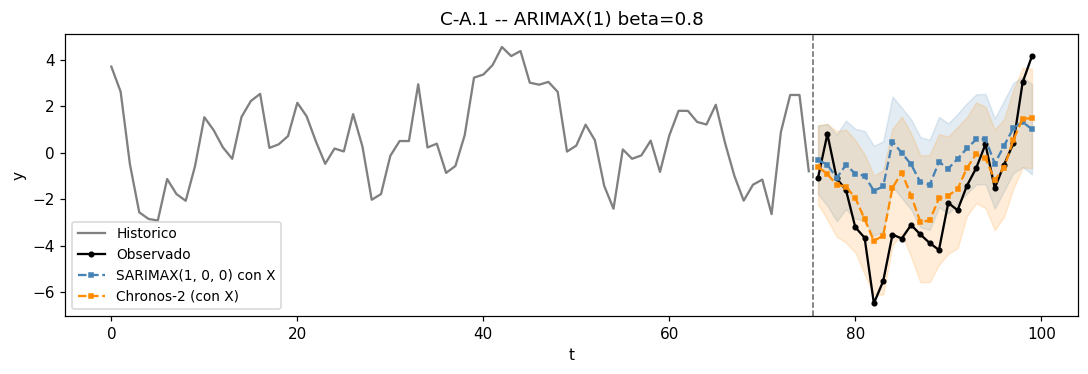

In [3]:
try:
    # C-A.1 -- ARIMAX(1) beta=0.8
    dgp_C_A_1 = ARIMAX_DGP(seed=SEED)
    make_models_C_A_1 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_A_1 = dict(phi=0.6, beta=0.8, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-A.1 -- ARIMAX(1) beta=0.8", dgp_C_A_1,
                   dgp_params_C_A_1, CHECKS_ARIMAX)
    res_C_A_1 = run_exp_cov(
        dgp_C_A_1, make_models_C_A_1, dgp_params_C_A_1,
        exp_id="C-A.1",
    )
    log("\n" + "="*60 + "\nC-A.1 -- ARIMAX(1) beta=0.8\n" + "="*60)
    build_grid_table(res_C_A_1, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_A_1, make_models_C_A_1(200),
                        dgp_params_C_A_1,
                        title="C-A.1 -- ARIMAX(1) beta=0.8")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-A.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### C-A.2 — ARIMAX(1) efecto medio (beta = 0.5)

**DGP:** $Y_t = 0.6\,Y_{t-1} + 0.5\,X_t + \varepsilon_t$.

**Hipotesis:** punto intermedio entre C-A.1 y C-A.3 — permite ver la curva de utilidad de la covariable como funcion de $\beta$.


17:30:59  ────────────────────────────────────────────────────────────
17:30:59  VERIFICACION DGP: C-A.2 -- ARIMAX(1) beta=0.5
17:30:59  ────────────────────────────────────────────────────────────
17:30:59    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
17:30:59    [PASS] Y media ~ 0: media=-0.2041, tol=+/-0.3486 (HAC bw=6)
17:30:59    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
17:30:59    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696], rho_x_DGP=0.7
17:30:59    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.6553, beta=0.5
17:31:00    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-2.8918 -1.9654 -1.326 ]
17:31:00    -> TODAS LAS VERIFICACIONES PASARON
17:31:00  Exp C-A.2: 4 ejecucion(es) -> (T=25, H=6, R=500), (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
17:31:00    T=25 H=6, R=500: cargando exp_C-A_2_T25_R500.csv
17:31:00    T=50 H=18, R=500: cargando exp_C-A_2_T50_R500.csv
17:31:00    T=100 H=24, R=500: cargan

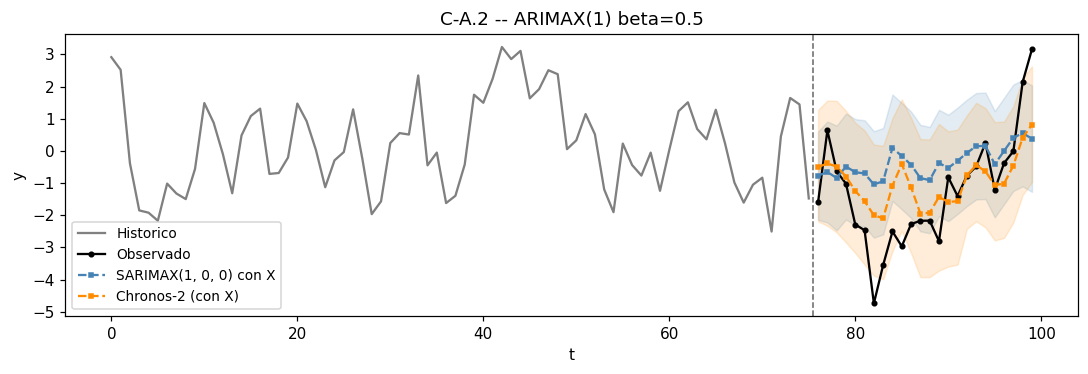

In [4]:
try:
    # C-A.2 -- ARIMAX(1) beta=0.5
    dgp_C_A_2 = ARIMAX_DGP(seed=SEED)
    make_models_C_A_2 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_A_2 = dict(phi=0.6, beta=0.5, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-A.2 -- ARIMAX(1) beta=0.5", dgp_C_A_2,
                   dgp_params_C_A_2, CHECKS_ARIMAX)
    res_C_A_2 = run_exp_cov(
        dgp_C_A_2, make_models_C_A_2, dgp_params_C_A_2,
        exp_id="C-A.2",
    )
    log("\n" + "="*60 + "\nC-A.2 -- ARIMAX(1) beta=0.5\n" + "="*60)
    build_grid_table(res_C_A_2, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_A_2, make_models_C_A_2(200),
                        dgp_params_C_A_2,
                        title="C-A.2 -- ARIMAX(1) beta=0.5")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-A.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### C-A.3 — ARIMAX(1) efecto debil (beta = 0.2)

**DGP:** $Y_t = 0.6\,Y_{t-1} + 0.2\,X_t + \varepsilon_t$.

**Hipotesis:** la covariable aporta poca senal frente al ruido $\varepsilon_t$. SARIMAX deberia dominar (parsimonia gana cuando la senal es debil).


17:31:01  ────────────────────────────────────────────────────────────
17:31:01  VERIFICACION DGP: C-A.3 -- ARIMAX(1) beta=0.2
17:31:01  ────────────────────────────────────────────────────────────
17:31:02    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
17:31:02    [PASS] Y media ~ 0: media=-0.1371, tol=+/-0.2282 (HAC bw=6)
17:31:02    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
17:31:02    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696], rho_x_DGP=0.7
17:31:02    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.3551, beta=0.2
17:31:02    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-1.8586 -1.2023 -0.7845]
17:31:02    -> TODAS LAS VERIFICACIONES PASARON
17:31:02  Exp C-A.3: 4 ejecucion(es) -> (T=25, H=6, R=500), (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
17:31:02    T=25 H=6, R=500: cargando exp_C-A_3_T25_R500.csv
17:31:02    T=50 H=18, R=500: cargando exp_C-A_3_T50_R500.csv
17:31:02    T=100 H=24, R=500: cargan

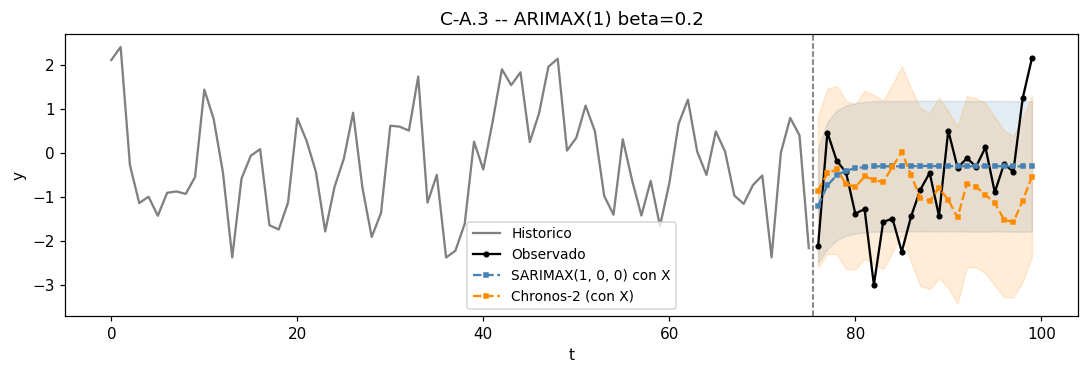

In [5]:
try:
    # C-A.3 -- ARIMAX(1) beta=0.2
    dgp_C_A_3 = ARIMAX_DGP(seed=SEED)
    make_models_C_A_3 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_A_3 = dict(phi=0.6, beta=0.2, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-A.3 -- ARIMAX(1) beta=0.2", dgp_C_A_3,
                   dgp_params_C_A_3, CHECKS_ARIMAX)
    res_C_A_3 = run_exp_cov(
        dgp_C_A_3, make_models_C_A_3, dgp_params_C_A_3,
        exp_id="C-A.3",
    )
    log("\n" + "="*60 + "\nC-A.3 -- ARIMAX(1) beta=0.2\n" + "="*60)
    build_grid_table(res_C_A_3, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_A_3, make_models_C_A_3(200),
                        dgp_params_C_A_3,
                        title="C-A.3 -- ARIMAX(1) beta=0.2")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-A.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### C-A.4 — Covariable casi raiz unitaria (rho_x = 0.95)

**DGP:** $Y_t = 0.6\,Y_{t-1} + 0.5\,X_t + \varepsilon_t$, $X_t = 0.95\,X_{t-1} + \eta_t$.

**Hipotesis:** $X$ es muy persistente — casi $I(1)$ — lo cual hace que su nivel sea informativo de largo plazo. Chronos podria aprovechar mejor esta inercia frente a SARIMAX.


17:31:04  ────────────────────────────────────────────────────────────
17:31:04  VERIFICACION DGP: C-A.4 -- rho_x=0.95
17:31:04  ────────────────────────────────────────────────────────────
17:31:04    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
17:31:04    [PASS] Y media ~ 0: media=-0.7018, tol=+/-0.8662 (HAC bw=6)
17:31:04    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
17:31:04    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.943], rho_x_DGP=0.95
17:31:04    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.9155, beta=0.5
17:31:05    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-0.1934 -0.1488 -0.1013]
17:31:05    -> TODAS LAS VERIFICACIONES PASARON
17:31:05  Exp C-A.4: 4 ejecucion(es) -> (T=25, H=6, R=500), (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
17:31:05    T=25 H=6, R=500: cargando exp_C-A_4_T25_R500.csv
17:31:05    T=50 H=18, R=500: cargando exp_C-A_4_T50_R500.csv
17:31:05    T=100 H=24, R=500: cargando exp_

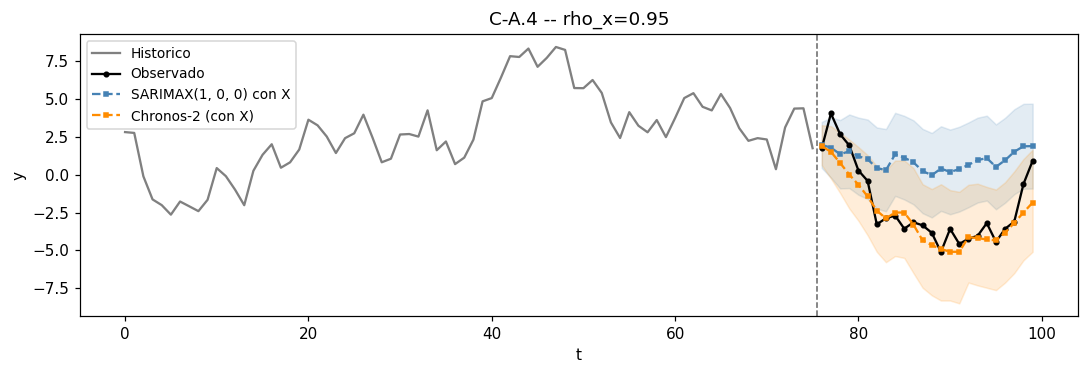

In [6]:
try:
    # C-A.4 -- rho_x=0.95
    dgp_C_A_4 = ARIMAX_DGP(seed=SEED)
    make_models_C_A_4 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_A_4 = dict(phi=0.6, beta=0.5, sigma_y=1.0, sigma_x=1.0, rho_x=0.95)
    verify_dgp_cov("C-A.4 -- rho_x=0.95", dgp_C_A_4,
                   dgp_params_C_A_4, CHECKS_ARIMAX)
    res_C_A_4 = run_exp_cov(
        dgp_C_A_4, make_models_C_A_4, dgp_params_C_A_4,
        exp_id="C-A.4",
    )
    log("\n" + "="*60 + "\nC-A.4 -- rho_x=0.95\n" + "="*60)
    build_grid_table(res_C_A_4, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_A_4, make_models_C_A_4(200),
                        dgp_params_C_A_4,
                        title="C-A.4 -- rho_x=0.95")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-A.4 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### C-A.5 — Covariable cercana a ruido blanco (rho_x = 0.0)

**DGP:** $Y_t = 0.6\,Y_{t-1} + 0.5\,X_t + \varepsilon_t$, $X_t = \eta_t$.

**Hipotesis:** $X$ no tiene estructura predecible — su valor *futuro* sigue siendo conocido (covariable observada), pero no hay senal en su trayectoria pasada. La utilidad del componente exogeno se reduce al efecto contemporaneo del nivel futuro.


17:31:08  ────────────────────────────────────────────────────────────
17:31:08  VERIFICACION DGP: C-A.5 -- rho_x=0.0
17:31:08  ────────────────────────────────────────────────────────────
17:31:08    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
17:31:08    [PASS] Y media ~ 0: media=-0.1255, tol=+/-0.2262 (HAC bw=6)
17:31:08    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
17:31:08    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[-0.014], rho_x_DGP=0.0
17:31:08    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.3779, beta=0.5
17:31:08    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-2.2551 -0.6438 -0.4204]
17:31:08    -> TODAS LAS VERIFICACIONES PASARON
17:31:08  Exp C-A.5: 4 ejecucion(es) -> (T=25, H=6, R=500), (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
17:31:08    T=25 H=6, R=500: cargando exp_C-A_5_T25_R500.csv
17:31:08    T=50 H=18, R=500: cargando exp_C-A_5_T50_R500.csv
17:31:08    T=100 H=24, R=500: cargando exp_C

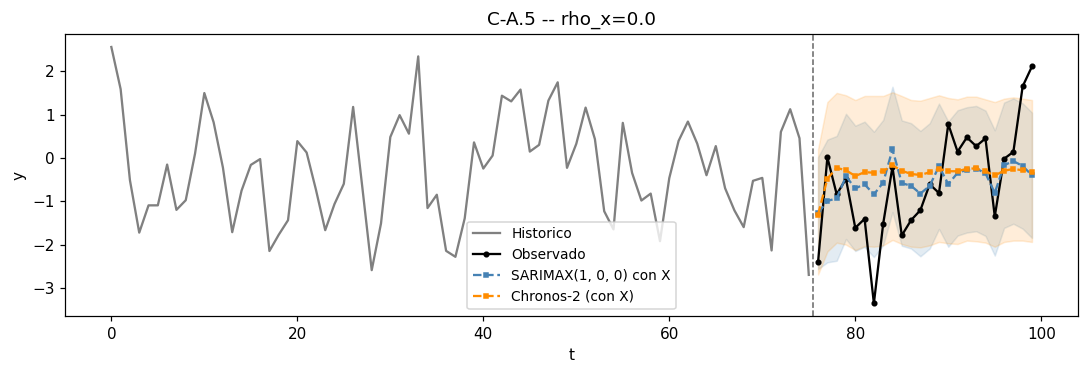

In [7]:
try:
    # C-A.5 -- rho_x=0.0
    dgp_C_A_5 = ARIMAX_DGP(seed=SEED)
    make_models_C_A_5 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_A_5 = dict(phi=0.6, beta=0.5, sigma_y=1.0, sigma_x=1.0, rho_x=0.0)
    verify_dgp_cov("C-A.5 -- rho_x=0.0", dgp_C_A_5,
                   dgp_params_C_A_5, CHECKS_ARIMAX)
    res_C_A_5 = run_exp_cov(
        dgp_C_A_5, make_models_C_A_5, dgp_params_C_A_5,
        exp_id="C-A.5",
    )
    log("\n" + "="*60 + "\nC-A.5 -- rho_x=0.0\n" + "="*60)
    build_grid_table(res_C_A_5, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_A_5, make_models_C_A_5(200),
                        dgp_params_C_A_5,
                        title="C-A.5 -- rho_x=0.0")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-A.5 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


---
## Bloque C-B — ARIMAX con dinamica AR mas rica (2 exps)

Explora si Chronos sigue capturando la senal exogena cuando la dinamica
autoregresiva de $Y$ se vuelve mas dificil:

- **C-B.1**: alta persistencia ($\phi = 0.9$) — el componente AR domina sobre la covariable.
- **C-B.2**: signo negativo ($\phi = -0.6$) — dinamica oscilatoria, ACF alternante.

Notese que `ARIMAX_DGP` solo expone `phi` escalar (AR(1)); no se simula AR(2)
sin extender el DGP. La cobertura de dinamicas mas complejas queda implicita
en estos dos casos limite.


### C-B.1 — ARIMAX(1) alta persistencia (phi = 0.9)

**DGP:** $Y_t = 0.9\,Y_{t-1} + 0.5\,X_t + \varepsilon_t$, $X_t = 0.7\,X_{t-1} + \eta_t$.

**Hipotesis:** el AR es casi raiz unitaria y domina la dinamica; el aporte marginal de la covariable es secundario. Mide si Chronos identifica correctamente la persistencia interna sin sobre-pesar la senal exogena.


17:31:10  ────────────────────────────────────────────────────────────
17:31:10  VERIFICACION DGP: C-B.1 -- ARIMAX(1) phi=0.9
17:31:10  ────────────────────────────────────────────────────────────
17:31:10    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
17:31:10    [PASS] Y media ~ 0: media=-0.8260, tol=+/-0.8992 (HAC bw=6)
17:31:10    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
17:31:10    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696], rho_x_DGP=0.7
17:31:10    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.5083, beta=0.5
17:31:10    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-0.9152 -0.6101 -0.407 ]
17:31:10    -> TODAS LAS VERIFICACIONES PASARON
17:31:10  Exp C-B.1: 4 ejecucion(es) -> (T=25, H=6, R=500), (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
17:31:10    T=25 H=6, R=500: cargando exp_C-B_1_T25_R500.csv
17:31:10    T=50 H=18, R=500: cargando exp_C-B_1_T50_R500.csv
17:31:10    T=100 H=24, R=500: cargand

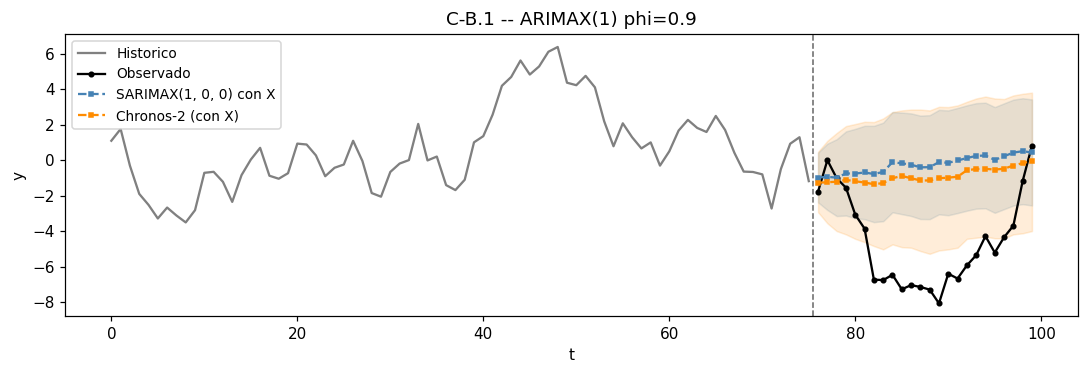

In [8]:
try:
    # C-B.1 -- ARIMAX(1) phi=0.9
    dgp_C_B_1 = ARIMAX_DGP(seed=SEED)
    make_models_C_B_1 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_B_1 = dict(phi=0.9, beta=0.5, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-B.1 -- ARIMAX(1) phi=0.9", dgp_C_B_1,
                   dgp_params_C_B_1, CHECKS_ARIMAX)
    res_C_B_1 = run_exp_cov(
        dgp_C_B_1, make_models_C_B_1, dgp_params_C_B_1,
        exp_id="C-B.1",
    )
    log("\n" + "="*60 + "\nC-B.1 -- ARIMAX(1) phi=0.9\n" + "="*60)
    build_grid_table(res_C_B_1, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_B_1, make_models_C_B_1(200),
                        dgp_params_C_B_1,
                        title="C-B.1 -- ARIMAX(1) phi=0.9")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-B.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### C-B.2 — ARIMAX(1) dinamica oscilatoria (phi = -0.6)

**DGP:** $Y_t = -0.6\,Y_{t-1} + 0.5\,X_t + \varepsilon_t$, $X_t = 0.7\,X_{t-1} + \eta_t$.

**Hipotesis:** ACF alternante en signo. SARIMAX(1,0,0) captura el AR negativo; Chronos enfrenta un patron mas inusual en su pretraining (donde dominan series con $\phi > 0$).


17:31:12  ────────────────────────────────────────────────────────────
17:31:12  VERIFICACION DGP: C-B.2 -- ARIMAX(1) phi=-0.6
17:31:12  ────────────────────────────────────────────────────────────
17:31:12    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
17:31:12    [PASS] Y media ~ 0: media=-0.0496, tol=+/-0.1026 (HAC bw=6)
17:31:12    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
17:31:12    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696], rho_x_DGP=0.7
17:31:12    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.3547, beta=0.5
17:31:12    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-1.6464 -0.1377 -0.6462]
17:31:12    -> TODAS LAS VERIFICACIONES PASARON
17:31:12  Exp C-B.2: 4 ejecucion(es) -> (T=25, H=6, R=500), (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
17:31:12    T=25 H=6, R=500: cargando exp_C-B_2_T25_R500.csv
17:31:12    T=50 H=18, R=500: cargando exp_C-B_2_T50_R500.csv
17:31:12    T=100 H=24, R=500: cargan

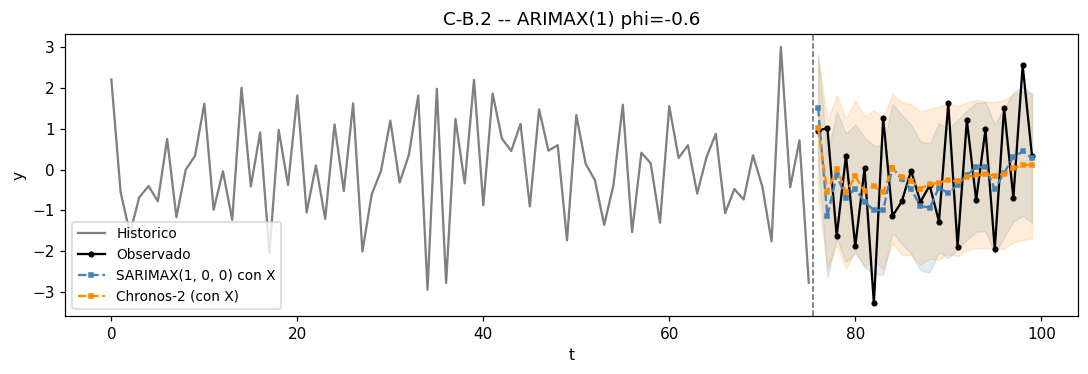

In [9]:
try:
    # C-B.2 -- ARIMAX(1) phi=-0.6
    dgp_C_B_2 = ARIMAX_DGP(seed=SEED)
    make_models_C_B_2 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_B_2 = dict(phi=-0.6, beta=0.5, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-B.2 -- ARIMAX(1) phi=-0.6", dgp_C_B_2,
                   dgp_params_C_B_2, CHECKS_ARIMAX)
    res_C_B_2 = run_exp_cov(
        dgp_C_B_2, make_models_C_B_2, dgp_params_C_B_2,
        exp_id="C-B.2",
    )
    log("\n" + "="*60 + "\nC-B.2 -- ARIMAX(1) phi=-0.6\n" + "="*60)
    build_grid_table(res_C_B_2, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_B_2, make_models_C_B_2(200),
                        dgp_params_C_B_2,
                        title="C-B.2 -- ARIMAX(1) phi=-0.6")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-B.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


---
## Bloque C-C — ARIMAX con multiples covariables (3 exps)

Mide como escala la performance cuando hay mas de un regresor exogeno.

**DGP:** $Y_t = 0.6\,Y_{t-1} + \beta_1 X_{1t} + \beta_2 X_{2t} + \varepsilon_t$,
con $X_{i,t} = 0.7 X_{i,t-1} + \eta_{i,t}$ independientes.

Variantes:
- **C-C.1**: efectos asimetricos ($\beta_1 = 0.8$, $\beta_2 = 0.4$).
- **C-C.2**: efectos balanceados ($\beta_1 = \beta_2 = 0.5$).
- **C-C.3**: capacidad de filtrado — un regresor relevante y otro nulo
  ($\beta_1 = 0.8$, $\beta_2 = 0.0$).


### C-C.1 — Dos covariables asimetricas (beta1=0.8, beta2=0.4)

**DGP:** $Y_t = 0.6\,Y_{t-1} + 0.8\,X_{1t} + 0.4\,X_{2t} + \varepsilon_t$.

**Hipotesis:** SARIMAX especifica ambos regresores; Chronos debe distinguir su peso relativo sin senal de cuales son mas importantes. Replica Exp 3.3.


17:31:13  ────────────────────────────────────────────────────────────
17:31:13  VERIFICACION DGP: C-C.1 -- ARIMAX 2-cov asimetricas
17:31:13  ────────────────────────────────────────────────────────────
17:31:13    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
17:31:13    [PASS] Y media ~ 0: media=-0.1986, tol=+/-0.5346 (HAC bw=6)
17:31:14    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0, 0.0]
17:31:14    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696, 0.693], rho_x_DGP=0.7
17:31:14    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.7197, beta1=0.8
17:31:14    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-5.1802 -3.2539 -2.115 ]
17:31:14    -> TODAS LAS VERIFICACIONES PASARON
17:31:14  Exp C-C.1: 4 ejecucion(es) -> (T=25, H=6, R=500), (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
17:31:14    T=25 H=6, R=500: cargando exp_C-C_1_T25_R500.csv
17:31:14    T=50 H=18, R=500: cargando exp_C-C_1_T50_R500.csv
17:31:14    T=100 

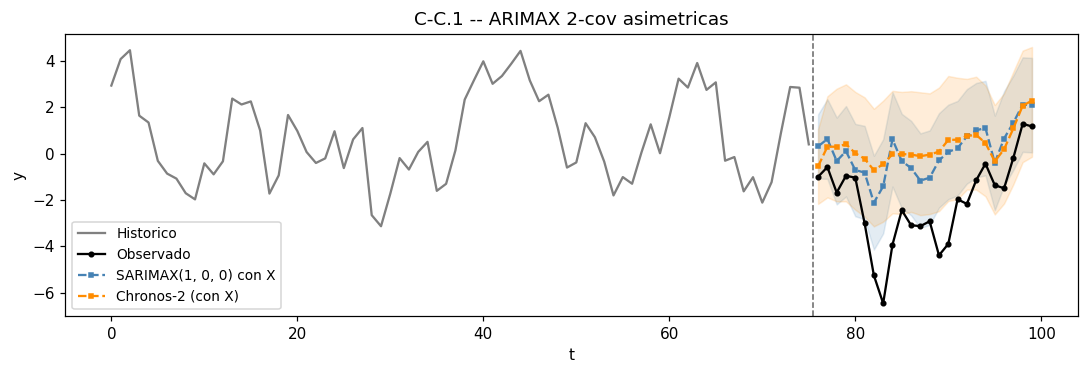

In [10]:
try:
    # C-C.1 -- ARIMAX 2-cov asimetricas
    dgp_C_C_1 = ARIMAX2Cov_DGP(seed=SEED)
    make_models_C_C_1 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov2,
    ]
    dgp_params_C_C_1 = dict(phi=0.6, beta1=0.8, beta2=0.4, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-C.1 -- ARIMAX 2-cov asimetricas", dgp_C_C_1,
                   dgp_params_C_C_1, CHECKS_ARIMAX)
    res_C_C_1 = run_exp_cov(
        dgp_C_C_1, make_models_C_C_1, dgp_params_C_C_1,
        exp_id="C-C.1",
    )
    log("\n" + "="*60 + "\nC-C.1 -- ARIMAX 2-cov asimetricas\n" + "="*60)
    build_grid_table(res_C_C_1, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_C_1, make_models_C_C_1(200),
                        dgp_params_C_C_1,
                        title="C-C.1 -- ARIMAX 2-cov asimetricas")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-C.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### C-C.2 — Dos covariables balanceadas (beta1=beta2=0.5)

**DGP:** $Y_t = 0.6\,Y_{t-1} + 0.5\,X_{1t} + 0.5\,X_{2t} + \varepsilon_t$.

**Hipotesis:** efectos iguales — no hay informacion previa sobre cual regresor pesa mas. Ambos modelos deberian explotarlos equitativamente.


17:31:15  ────────────────────────────────────────────────────────────
17:31:15  VERIFICACION DGP: C-C.2 -- ARIMAX 2-cov balanceadas
17:31:15  ────────────────────────────────────────────────────────────
17:31:16    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
17:31:16    [PASS] Y media ~ 0: media=-0.1641, tol=+/-0.4328 (HAC bw=6)
17:31:16    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0, 0.0]
17:31:16    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696, 0.693], rho_x_DGP=0.7
17:31:16    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.5465, beta1=0.5
17:31:16    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-4.6537 -2.6401 -1.5481]
17:31:16    -> TODAS LAS VERIFICACIONES PASARON
17:31:16  Exp C-C.2: 4 ejecucion(es) -> (T=25, H=6, R=500), (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
17:31:16    T=25 H=6, R=500: cargando exp_C-C_2_T25_R500.csv
17:31:16    T=50 H=18, R=500: cargando exp_C-C_2_T50_R500.csv
17:31:16    T=100 

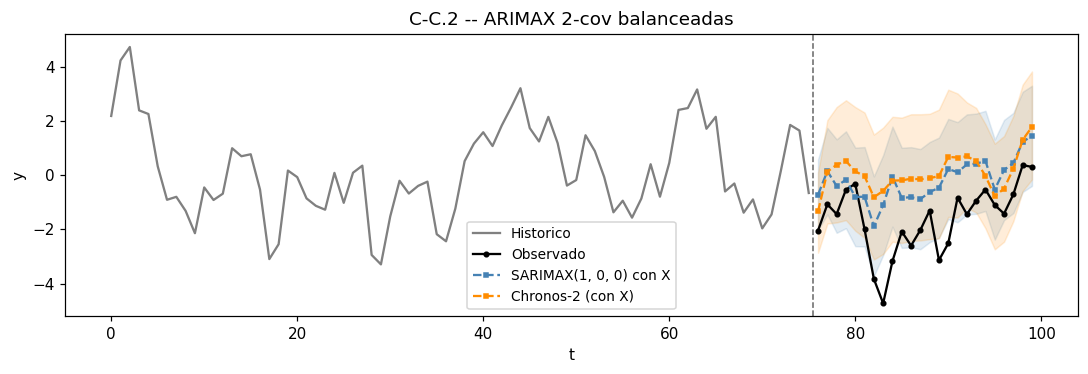

In [11]:
try:
    # C-C.2 -- ARIMAX 2-cov balanceadas
    dgp_C_C_2 = ARIMAX2Cov_DGP(seed=SEED)
    make_models_C_C_2 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov2,
    ]
    dgp_params_C_C_2 = dict(phi=0.6, beta1=0.5, beta2=0.5, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-C.2 -- ARIMAX 2-cov balanceadas", dgp_C_C_2,
                   dgp_params_C_C_2, CHECKS_ARIMAX)
    res_C_C_2 = run_exp_cov(
        dgp_C_C_2, make_models_C_C_2, dgp_params_C_C_2,
        exp_id="C-C.2",
    )
    log("\n" + "="*60 + "\nC-C.2 -- ARIMAX 2-cov balanceadas\n" + "="*60)
    build_grid_table(res_C_C_2, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_C_2, make_models_C_C_2(200),
                        dgp_params_C_C_2,
                        title="C-C.2 -- ARIMAX 2-cov balanceadas")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-C.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### C-C.3 — Una covariable relevante y otra nula (beta1=0.8, beta2=0.0)

**DGP:** $Y_t = 0.6\,Y_{t-1} + 0.8\,X_{1t} + 0\cdot X_{2t} + \varepsilon_t$.

**Hipotesis:** capacidad de filtrado/regularizacion. SARIMAX estima $\hat\beta_2 \to 0$ con muestra grande; Chronos no estima coeficientes — testea si el ruido de la covariable irrelevante degrada sus pronosticos.


17:31:18  ────────────────────────────────────────────────────────────
17:31:18  VERIFICACION DGP: C-C.3 -- ARIMAX 2-cov filtrado
17:31:18  ────────────────────────────────────────────────────────────
17:31:18    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
17:31:18    [PASS] Y media ~ 0: media=-0.0688, tol=+/-0.4773 (HAC bw=6)
17:31:18    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0, 0.0]
17:31:18    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696, 0.693], rho_x_DGP=0.7
17:31:18    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.7688, beta1=0.8
17:31:19    [PASS] SARIMAX(1,0,0) con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-3.5318 -2.4398 -1.6507]
17:31:19    -> TODAS LAS VERIFICACIONES PASARON
17:31:19  Exp C-C.3: 4 ejecucion(es) -> (T=25, H=6, R=500), (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
17:31:19    T=25 H=6, R=500: cargando exp_C-C_3_T25_R500.csv
17:31:19    T=50 H=18, R=500: cargando exp_C-C_3_T50_R500.csv
17:31:19    T=100 H=2

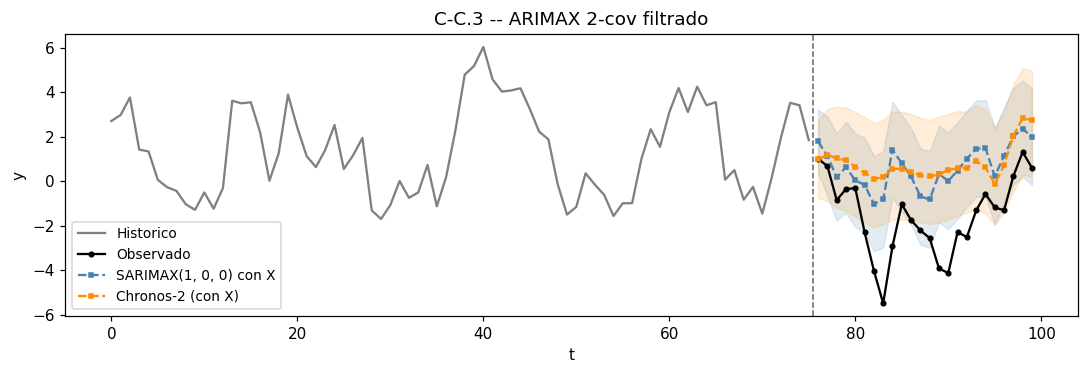

In [12]:
try:
    # C-C.3 -- ARIMAX 2-cov filtrado
    dgp_C_C_3 = ARIMAX2Cov_DGP(seed=SEED)
    make_models_C_C_3 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov2,
    ]
    dgp_params_C_C_3 = dict(phi=0.6, beta1=0.8, beta2=0.0, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-C.3 -- ARIMAX 2-cov filtrado", dgp_C_C_3,
                   dgp_params_C_C_3, CHECKS_ARIMAX)
    res_C_C_3 = run_exp_cov(
        dgp_C_C_3, make_models_C_C_3, dgp_params_C_C_3,
        exp_id="C-C.3",
    )
    log("\n" + "="*60 + "\nC-C.3 -- ARIMAX 2-cov filtrado\n" + "="*60)
    build_grid_table(res_C_C_3, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_C_3, make_models_C_C_3(200),
                        dgp_params_C_C_3,
                        title="C-C.3 -- ARIMAX 2-cov filtrado")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-C.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


---
## Bloque C-D — ARIMAX con volatilidad condicional (3 exps)

La covariable entra en la media y/o en la varianza condicional del error.

**DGP:** $Y_t = 0.4\,Y_{t-1} + \beta_{\text{mean}}\,X_t + \varepsilon_t$,
con $\sigma_t^2 = \omega + \alpha\,\varepsilon_{t-1}^2
+ \beta_{\text{garch}}\,\sigma_{t-1}^2 + \delta_{\text{var}}\,X_t^2$
y $X_t = 0.7\,X_{t-1} + \eta_t$.

Variantes:
- **C-D.1**: efecto solo en la media ($\beta_{\text{mean}} = 0.5$, $\delta_{\text{var}} = 0$).
- **C-D.2**: efecto en media y varianza ($\beta_{\text{mean}} = 0.5$, $\delta_{\text{var}} = 0.1$).
- **C-D.3**: efecto solo en varianza ($\beta_{\text{mean}} = 0$, $\delta_{\text{var}} = 0.3$).

SARIMAX no modela la varianza condicional explicitamente — pierde calibracion
en intervalos cuando $\delta_{\text{var}} > 0$. Aqui se mide si Chronos
absorbe esa estructura implicitamente.


### C-D.1 — ARIMAX-GARCH: efecto solo en la media (delta_var = 0)

**DGP:** $Y_t = 0.4\,Y_{t-1} + 0.5\,X_t + \varepsilon_t$, $\sigma_t^2 = 0.1 + 0.1\varepsilon_{t-1}^2 + 0.75\sigma_{t-1}^2$.

**Hipotesis:** GARCH puro sin influencia exogena en la varianza. SARIMAX no modela $\sigma_t$ y tendra intervalos mal calibrados; Chronos quantilico puede capturar la heteroscedasticidad implicitamente.


17:31:21  ────────────────────────────────────────────────────────────
17:31:21  VERIFICACION DGP: C-D.1 -- ARIMAX-GARCH solo media
17:31:21  ────────────────────────────────────────────────────────────
17:31:21    [PASS] Y estacionaria en media (ADF): ADF Y p=0.0000 (umbral 0.05)
17:31:21    [PASS] Y media ~ 0: media=-0.0805, tol=+/-0.2291 (HAC bw=6)
17:31:21    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
17:31:21    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.697], rho_x_DGP=0.7
17:31:21    [PASS] Efectos ARCH detectables en residuos: LB(10) sobre resid^2: p=0.0000 (se espera <0.05)
17:31:22    [PASS] SARIMAX con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-0.3701 -0.4409 -0.2161]
17:31:22    -> TODAS LAS VERIFICACIONES PASARON
17:31:22  Exp C-D.1: 4 ejecucion(es) -> (T=25, H=6, R=500), (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
17:31:22    T=25 H=6, R=500: cargando exp_C-D_1_T25_R500.csv
17:31:22    T=50 H=18, R=500: cargando exp_C-D_1_T50_R500.csv
17:31

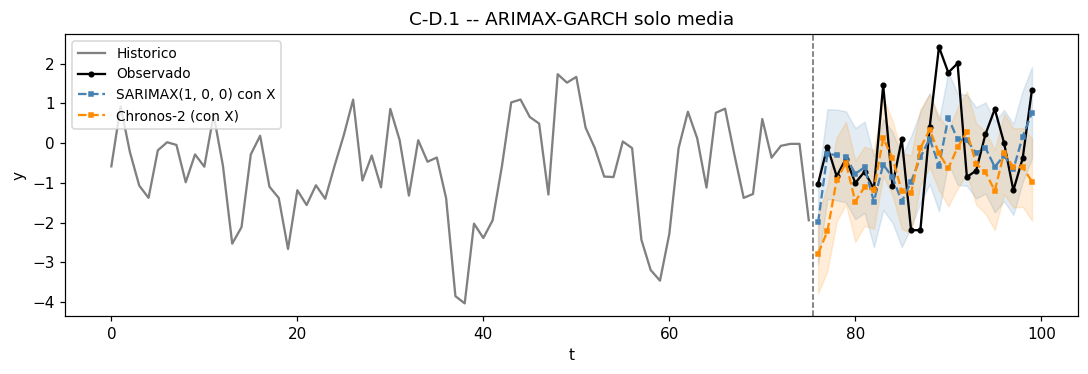

In [13]:
try:
    # C-D.1 -- ARIMAX-GARCH solo media
    dgp_C_D_1 = ARIMAX_GARCH_DGP(seed=SEED)
    make_models_C_D_1 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_D_1 = dict(phi=0.4, beta_mean=0.5, omega=0.1, alpha=0.1, beta_garch=0.75, delta_var=0.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-D.1 -- ARIMAX-GARCH solo media", dgp_C_D_1,
                   dgp_params_C_D_1, CHECKS_ARIMAX_GARCH)
    res_C_D_1 = run_exp_cov(
        dgp_C_D_1, make_models_C_D_1, dgp_params_C_D_1,
        exp_id="C-D.1",
    )
    log("\n" + "="*60 + "\nC-D.1 -- ARIMAX-GARCH solo media\n" + "="*60)
    build_grid_table(res_C_D_1, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_D_1, make_models_C_D_1(200),
                        dgp_params_C_D_1,
                        title="C-D.1 -- ARIMAX-GARCH solo media")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-D.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### C-D.2 — ARIMAX-GARCH: media + varianza (delta_var = 0.1)

**DGP:** misma estructura, con $X_t^2$ inyectado en la varianza ($\delta_{\text{var}} = 0.1$).

**Hipotesis:** caso completo (replica Exp 3.5). La covariable contribuye a ambos momentos; SARIMAX solo captura el primero.


17:31:24  ────────────────────────────────────────────────────────────
17:31:24  VERIFICACION DGP: C-D.2 -- ARIMAX-GARCH media+var
17:31:24  ────────────────────────────────────────────────────────────
17:31:24    [PASS] Y estacionaria en media (ADF): ADF Y p=0.0000 (umbral 0.05)
17:31:24    [PASS] Y media ~ 0: media=-0.1007, tol=+/-0.2836 (HAC bw=6)
17:31:24    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
17:31:24    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.697], rho_x_DGP=0.7
17:31:24    [PASS] Efectos ARCH detectables en residuos: LB(10) sobre resid^2: p=0.0000 (se espera <0.05)
17:31:25    [PASS] SARIMAX con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-0.3736 -0.4596 -0.2363]
17:31:25    -> TODAS LAS VERIFICACIONES PASARON
17:31:25  Exp C-D.2: 4 ejecucion(es) -> (T=25, H=6, R=500), (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
17:31:25    T=25 H=6, R=500: cargando exp_C-D_2_T25_R500.csv
17:31:25    T=50 H=18, R=500: cargando exp_C-D_2_T50_R500.csv
17:31:

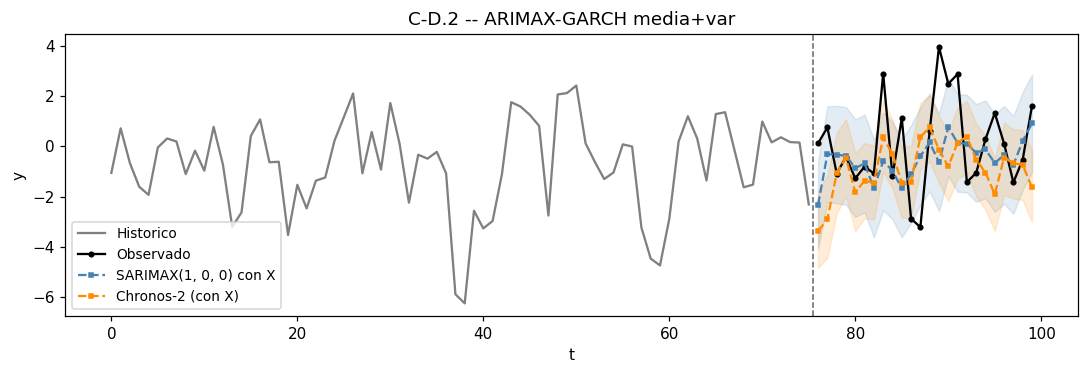

In [14]:
try:
    # C-D.2 -- ARIMAX-GARCH media+var
    dgp_C_D_2 = ARIMAX_GARCH_DGP(seed=SEED)
    make_models_C_D_2 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_D_2 = dict(phi=0.4, beta_mean=0.5, omega=0.1, alpha=0.1, beta_garch=0.75, delta_var=0.1, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-D.2 -- ARIMAX-GARCH media+var", dgp_C_D_2,
                   dgp_params_C_D_2, CHECKS_ARIMAX_GARCH)
    res_C_D_2 = run_exp_cov(
        dgp_C_D_2, make_models_C_D_2, dgp_params_C_D_2,
        exp_id="C-D.2",
    )
    log("\n" + "="*60 + "\nC-D.2 -- ARIMAX-GARCH media+var\n" + "="*60)
    build_grid_table(res_C_D_2, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_D_2, make_models_C_D_2(200),
                        dgp_params_C_D_2,
                        title="C-D.2 -- ARIMAX-GARCH media+var")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-D.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### C-D.3 — ARIMAX-GARCH: efecto solo en la varianza (beta_mean = 0)

**DGP:** $Y_t = 0.4\,Y_{t-1} + 0\cdot X_t + \varepsilon_t$, varianza con $\delta_{\text{var}} = 0.3$.

**Hipotesis:** la covariable no informa el nivel pero si la volatilidad. SARIMAX la incluye en la media y el coef estimado deberia ir a cero. Chronos debe identificar el canal de varianza para mejorar intervalos.


17:31:27  ────────────────────────────────────────────────────────────
17:31:27  VERIFICACION DGP: C-D.3 -- ARIMAX-GARCH solo varianza
17:31:27  ────────────────────────────────────────────────────────────
17:31:27    [PASS] Y estacionaria en media (ADF): ADF Y p=0.0000 (umbral 0.05)
17:31:27    [PASS] Y media ~ 0: media=-0.0461, tol=+/-0.2815 (HAC bw=6)
17:31:27    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
17:31:27    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.697], rho_x_DGP=0.7
17:31:27    [PASS] Efectos ARCH detectables en residuos: LB(10) sobre resid^2: p=0.0000 (se espera <0.05)
17:31:27    [PASS] SARIMAX con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-0.0432 -0.0584 -0.064 ]
17:31:27    -> TODAS LAS VERIFICACIONES PASARON
17:31:27  Exp C-D.3: 4 ejecucion(es) -> (T=25, H=6, R=500), (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
17:31:27    T=25 H=6, R=500: cargando exp_C-D_3_T25_R500.csv
17:31:27    T=50 H=18, R=500: cargando exp_C-D_3_T50_R500.csv
17

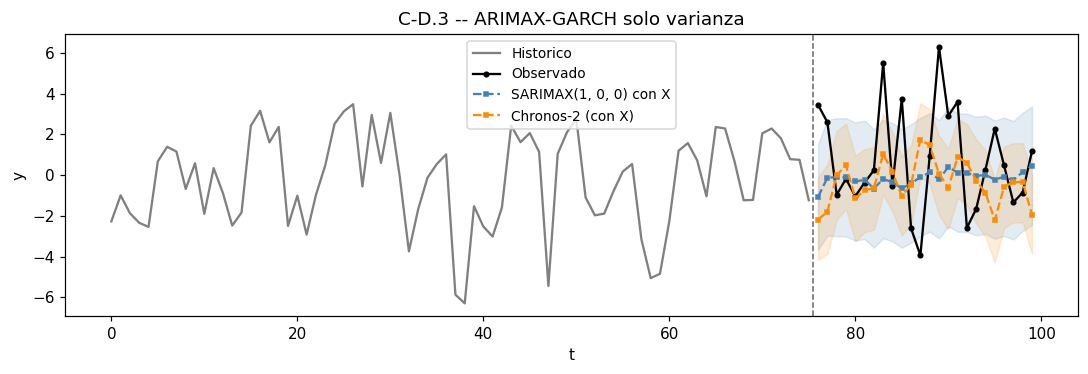

In [15]:
try:
    # C-D.3 -- ARIMAX-GARCH solo varianza
    dgp_C_D_3 = ARIMAX_GARCH_DGP(seed=SEED)
    make_models_C_D_3 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_D_3 = dict(phi=0.4, beta_mean=0.0, omega=0.1, alpha=0.1, beta_garch=0.75, delta_var=0.3, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-D.3 -- ARIMAX-GARCH solo varianza", dgp_C_D_3,
                   dgp_params_C_D_3, CHECKS_ARIMAX_GARCH)
    res_C_D_3 = run_exp_cov(
        dgp_C_D_3, make_models_C_D_3, dgp_params_C_D_3,
        exp_id="C-D.3",
    )
    log("\n" + "="*60 + "\nC-D.3 -- ARIMAX-GARCH solo varianza\n" + "="*60)
    build_grid_table(res_C_D_3, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_D_3, make_models_C_D_3(200),
                        dgp_params_C_D_3,
                        title="C-D.3 -- ARIMAX-GARCH solo varianza")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-D.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


---
## Bloque C-E — VARX bivariado (3 exps)

Sistema multivariado con covariable exogena comun:

$$\mathbf{Y}_t = A\,\mathbf{Y}_{t-1} + \boldsymbol{\gamma}\,X_t + \boldsymbol{\varepsilon}_t$$

con $\boldsymbol{\varepsilon}_t \sim \mathcal{N}(0, \Sigma)$, $A \in \mathbb{R}^{2 \times 2}$,
$\boldsymbol{\gamma} \in \mathbb{R}^2$, y $X_t$ AR(1) estacionaria.

Variantes:
- **C-E.1**: baseline ($A$ de dependencia debil, $\gamma$ asimetrico).
- **C-E.2**: dependencia cruzada y efecto exogeno fuertes simultaneamente.
- **C-E.3**: efecto exogeno debil ($\gamma$ bajo) — testea si Chronos joint
  separa la senal AR de la covariable.

**Modelos:** `VARMAX(1) con X` (clasico) vs `Chronos-2 joint (con X)`.


### C-E.1 — VARX bivariado baseline

**DGP:** $A = \begin{pmatrix} 0.5 & 0.1 \\ 0.1 & 0.5 \end{pmatrix}$, $\boldsymbol{\gamma} = (0.5, 0.3)$, $\Sigma$ con correlacion 0.3 off-diag.

**Hipotesis:** dependencia cruzada moderada y efecto exogeno asimetrico. Replica Exp 3.4.


17:31:29  ────────────────────────────────────────────────────────────
17:31:29  VERIFICACION DGP: C-E.1 -- VARX baseline
17:31:29  ────────────────────────────────────────────────────────────
17:31:29    [PASS] Estabilidad VAR (max|eig(A)|<1): max|lambda(A)|=0.6000 (umbral 0.999)
17:31:29    [PASS] Sigma PSD: min eig(Sigma)=0.700000
17:31:30    [PASS] X estacionaria (ADF): ADF X p=0.0000, rho_x_DGP=0.7
17:31:30    [PASS] Salida finita y std razonable: std(Y)=[1.591, 1.436]
17:31:30    [PASS] Senal de gamma en Y: Y1: corr=0.622, gamma=0.5 | Y2: corr=0.491, gamma=0.3
17:31:30    -> TODAS LAS VERIFICACIONES PASARON
17:31:30  Exp C-E.1: 4 ejecucion(es) -> (T=25, H=6, R=500), (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
17:31:30    T=25 H=6, R=500: cargando exp_C-E_1_T25_R500.csv
17:31:30    T=50 H=18, R=500: cargando exp_C-E_1_T50_R500.csv
17:31:30    T=100 H=24, R=500: cargando exp_C-E_1_T100_R500.csv
17:31:30    T=200 H=24, R=500: cargando exp_C-E_1_T200_R500.csv
17:3


--- Tabla 2: metricas multivariadas conjuntas (si disponibles) ---
17:31:30    [tabla joint] sin filas — el CSV no contiene metricas joint (probablemente el engine no inyecta var=-1; ignorar).


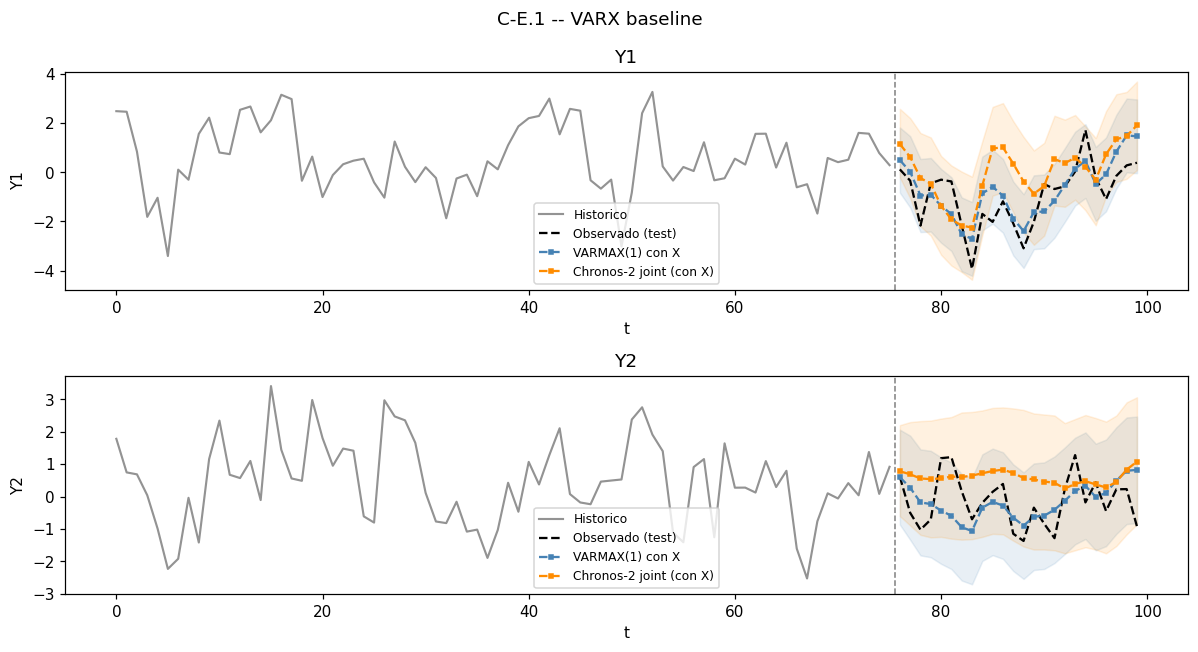

In [16]:
try:
    # C-E.1 -- VARX baseline
    dgp_C_E_1 = VARX_DGP(seed=SEED, A=[[0.5, 0.1], [0.1, 0.5]], gamma=[0.5, 0.3], Sigma=[[1.0, 0.3], [0.3, 1.0]], sigma_x=1.0, rho_x=0.7)
    make_models_C_E_1 = lambda T: [
        VARMAXModel(1),
        chronos_mv_cov1,
    ]
    dgp_params_C_E_1 = dict()
    verify_dgp_mv_cov("C-E.1 -- VARX baseline", dgp_C_E_1,
                      dgp_params_C_E_1, CHECKS_VARX)
    res_C_E_1 = run_exp_mv_cov(
        dgp_C_E_1, make_models_C_E_1, dgp_params_C_E_1,
        exp_id="C-E.1",
    )
    log("\n" + "="*60 + "\nC-E.1 -- VARX baseline\n" + "="*60)
    build_grid_table_mv(res_C_E_1, classical_name="VARMAX(1) con X",
                        var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (si disponibles) ---")
    build_grid_table_mv_joint(res_C_E_1, classical_name="VARMAX(1) con X")
    plot_simulation_mv_cov(dgp_C_E_1, make_models_C_E_1(200),
                            dgp_params_C_E_1, var_names=["Y1", "Y2"],
                            title="C-E.1 -- VARX baseline")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-E.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### C-E.2 — VARX dependencia y efecto exogeno fuertes

**DGP:** $A = \begin{pmatrix} 0.6 & 0.3 \\ 0.3 & 0.6 \end{pmatrix}$, $\boldsymbol{\gamma} = (0.8, 0.6)$.

**Hipotesis:** ambas fuentes de senal son fuertes simultaneamente. VARMAX deberia dominar (esta correctamente especificado); Chronos joint pone a prueba si captura la dependencia cruzada y el exogeno conjuntamente.


17:31:33  ────────────────────────────────────────────────────────────
17:31:33  VERIFICACION DGP: C-E.2 -- VARX dependencia fuerte
17:31:33  ────────────────────────────────────────────────────────────
17:31:33    [PASS] Estabilidad VAR (max|eig(A)|<1): max|lambda(A)|=0.9000 (umbral 0.999)
17:31:33    [PASS] Sigma PSD: min eig(Sigma)=0.700000
17:31:33    [PASS] X estacionaria (ADF): ADF X p=0.0000, rho_x_DGP=0.7
17:31:33    [PASS] Salida finita y std razonable: std(Y)=[4.786, 4.601]
17:31:33    [PASS] Senal de gamma en Y: Y1: corr=0.554, gamma=0.8 | Y2: corr=0.518, gamma=0.6
17:31:33    -> TODAS LAS VERIFICACIONES PASARON
17:31:33  Exp C-E.2: 4 ejecucion(es) -> (T=25, H=6, R=500), (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
17:31:33    T=25 H=6, R=500: cargando exp_C-E_2_T25_R500.csv
17:31:33    T=50 H=18, R=500: cargando exp_C-E_2_T50_R500.csv
17:31:33    T=100 H=24, R=500: cargando exp_C-E_2_T100_R500.csv
17:31:33    T=200 H=24, R=500: cargando exp_C-E_2_T200_R50


--- Tabla 2: metricas multivariadas conjuntas (si disponibles) ---
17:31:34    [tabla joint] sin filas — el CSV no contiene metricas joint (probablemente el engine no inyecta var=-1; ignorar).


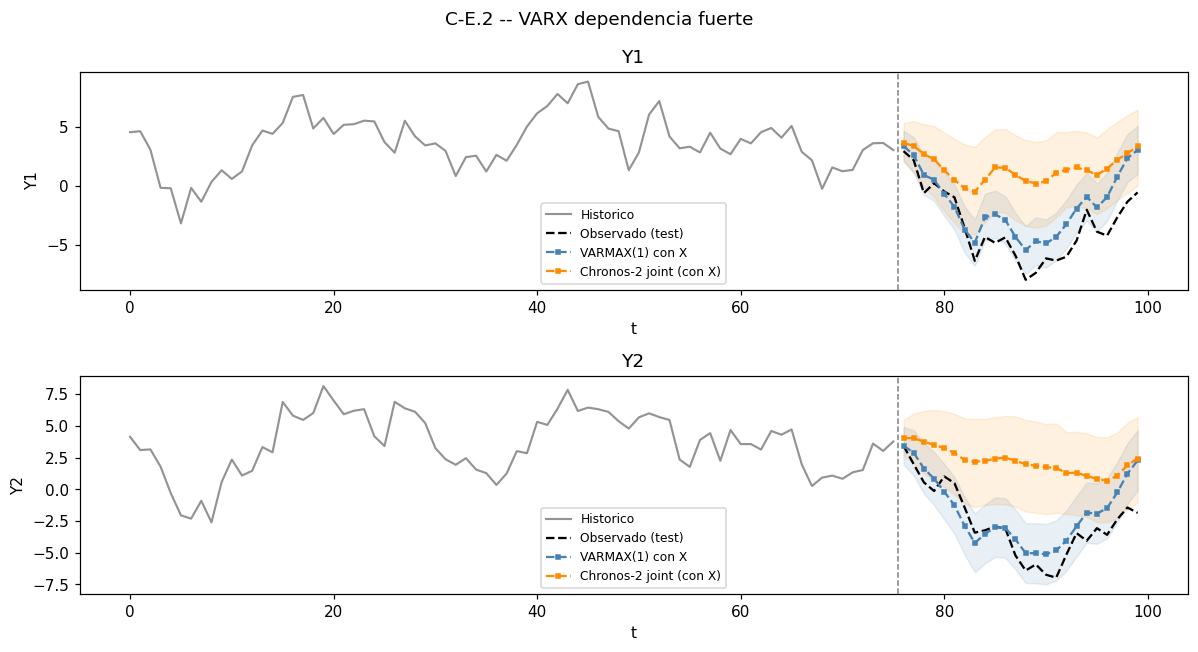

In [17]:
try:
    # C-E.2 -- VARX dependencia fuerte
    dgp_C_E_2 = VARX_DGP(seed=SEED, A=[[0.6, 0.3], [0.3, 0.6]], gamma=[0.8, 0.6], Sigma=[[1.0, 0.3], [0.3, 1.0]], sigma_x=1.0, rho_x=0.7)
    make_models_C_E_2 = lambda T: [
        VARMAXModel(1),
        chronos_mv_cov1,
    ]
    dgp_params_C_E_2 = dict()
    verify_dgp_mv_cov("C-E.2 -- VARX dependencia fuerte", dgp_C_E_2,
                      dgp_params_C_E_2, CHECKS_VARX)
    res_C_E_2 = run_exp_mv_cov(
        dgp_C_E_2, make_models_C_E_2, dgp_params_C_E_2,
        exp_id="C-E.2",
    )
    log("\n" + "="*60 + "\nC-E.2 -- VARX dependencia fuerte\n" + "="*60)
    build_grid_table_mv(res_C_E_2, classical_name="VARMAX(1) con X",
                        var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (si disponibles) ---")
    build_grid_table_mv_joint(res_C_E_2, classical_name="VARMAX(1) con X")
    plot_simulation_mv_cov(dgp_C_E_2, make_models_C_E_2(200),
                            dgp_params_C_E_2, var_names=["Y1", "Y2"],
                            title="C-E.2 -- VARX dependencia fuerte")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-E.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### C-E.3 — VARX efecto exogeno debil

**DGP:** $A$ baseline, $\boldsymbol{\gamma} = (0.2, 0.2)$.

**Hipotesis:** la dinamica cruzada de $\mathbf{Y}$ domina sobre $X$; testea si Chronos joint distingue correctamente la senal endogena del aporte marginal del exogeno cuando este es debil.


17:31:36  ────────────────────────────────────────────────────────────
17:31:36  VERIFICACION DGP: C-E.3 -- VARX efecto exogeno debil
17:31:36  ────────────────────────────────────────────────────────────
17:31:36    [PASS] Estabilidad VAR (max|eig(A)|<1): max|lambda(A)|=0.6000 (umbral 0.999)
17:31:36    [PASS] Sigma PSD: min eig(Sigma)=0.700000
17:31:36    [PASS] X estacionaria (ADF): ADF X p=0.0000, rho_x_DGP=0.7
17:31:36    [PASS] Salida finita y std razonable: std(Y)=[1.205, 1.269]
17:31:36    [PASS] Senal de gamma en Y: Y1: corr=0.277, gamma=0.2 | Y2: corr=0.335, gamma=0.2
17:31:36    -> TODAS LAS VERIFICACIONES PASARON
17:31:36  Exp C-E.3: 4 ejecucion(es) -> (T=25, H=6, R=500), (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
17:31:36    T=25 H=6, R=500: cargando exp_C-E_3_T25_R500.csv
17:31:36    T=50 H=18, R=500: cargando exp_C-E_3_T50_R500.csv
17:31:36    T=100 H=24, R=500: cargando exp_C-E_3_T100_R500.csv
17:31:36    T=200 H=24, R=500: cargando exp_C-E_3_T200_R


--- Tabla 2: metricas multivariadas conjuntas (si disponibles) ---
17:31:37    [tabla joint] sin filas — el CSV no contiene metricas joint (probablemente el engine no inyecta var=-1; ignorar).


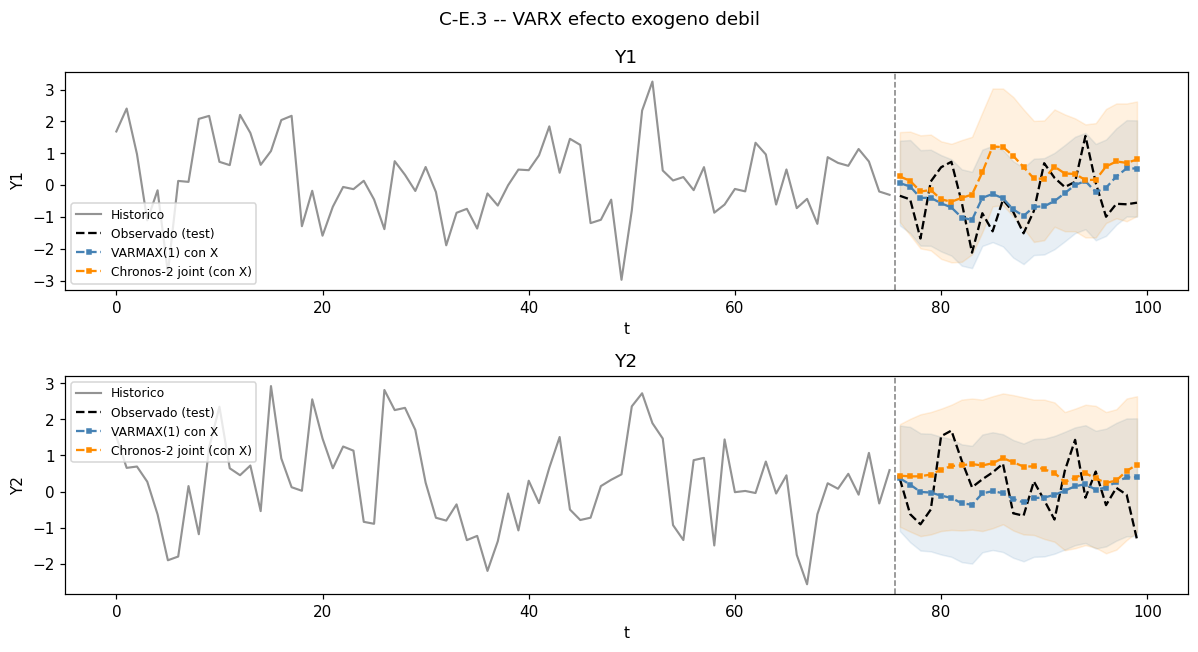

In [18]:
try:
    # C-E.3 -- VARX efecto exogeno debil
    dgp_C_E_3 = VARX_DGP(seed=SEED, A=[[0.5, 0.1], [0.1, 0.5]], gamma=[0.2, 0.2], Sigma=[[1.0, 0.3], [0.3, 1.0]], sigma_x=1.0, rho_x=0.7)
    make_models_C_E_3 = lambda T: [
        VARMAXModel(1),
        chronos_mv_cov1,
    ]
    dgp_params_C_E_3 = dict()
    verify_dgp_mv_cov("C-E.3 -- VARX efecto exogeno debil", dgp_C_E_3,
                      dgp_params_C_E_3, CHECKS_VARX)
    res_C_E_3 = run_exp_mv_cov(
        dgp_C_E_3, make_models_C_E_3, dgp_params_C_E_3,
        exp_id="C-E.3",
    )
    log("\n" + "="*60 + "\nC-E.3 -- VARX efecto exogeno debil\n" + "="*60)
    build_grid_table_mv(res_C_E_3, classical_name="VARMAX(1) con X",
                        var_names=["Y1", "Y2"])
    print("\n--- Tabla 2: metricas multivariadas conjuntas (si disponibles) ---")
    build_grid_table_mv_joint(res_C_E_3, classical_name="VARMAX(1) con X")
    plot_simulation_mv_cov(dgp_C_E_3, make_models_C_E_3(200),
                            dgp_params_C_E_3, var_names=["Y1", "Y2"],
                            title="C-E.3 -- VARX efecto exogeno debil")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-E.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


---
## Bloque C-F — Cointegracion ADL-ECM (2 exps)

Series $Y_t$, $X_t$ ambas $I(1)$ con relacion de equilibrio de largo plazo
$Y_t - X_t \sim I(0)$:

$$\Delta Y_t = \alpha_{\text{ecm}}\,(Y_{t-1} - X_{t-1}) + \Delta X_t + \eta_t$$

El parametro $\alpha_{\text{ecm}} < 0$ controla la velocidad de correccion
al equilibrio. Variantes:
- **C-F.1**: $\alpha_{\text{ecm}} = -0.3$ (correccion moderada).
- **C-F.2**: $\alpha_{\text{ecm}} = -0.6$ (correccion rapida).

**Modelos:** `ARDL-ECM` (clasico cointegrado), `SARIMAX(1,1,0) con X`
(benchmark sin estructura cointegrada), `Chronos-2 (con X)`.


### C-F.1 — Cointegracion ADL-ECM, correccion moderada (alpha_ecm = -0.3)

**DGP:** $\Delta Y_t = -0.3\,(Y_{t-1} - X_{t-1}) + \Delta X_t + \eta_t$, $X_t = X_{t-1} + u_t$ (random walk).

**Hipotesis:** ARDL-ECM (correctamente especificado) deberia dominar a horizontes largos donde la relacion de equilibrio se manifiesta. SARIMAX(1,1,0) ignora la senal de cointegracion; sirve de baseline diferenciado. Replica Exp 3.6.


17:31:39  ────────────────────────────────────────────────────────────
17:31:39  VERIFICACION DGP: C-F.1 -- ADL-ECM alpha_ecm=-0.3
17:31:39  ────────────────────────────────────────────────────────────
17:31:39    [PASS] Y es I(1) (ADF niveles/diferencias): ADF Y lvl=0.594, dif=0.000
17:31:39    [PASS] X es I(1) (ADF niveles/diferencias): X0: lvl=0.681, dif=0.000
17:31:39    [PASS] Y - X es I(0) (cointegracion): ADF(Y-X) p=0.0000 (se espera <0.05)
17:31:39    [PASS] ARDL-ECM fit+forecast: ARDL-ECM fit+forecast OK, primeros: [-13.0247 -14.3867 -16.3081]
17:31:39    -> TODAS LAS VERIFICACIONES PASARON
17:31:39  Exp C-F.1: 4 ejecucion(es) -> (T=25, H=6, R=500), (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
17:31:39    T=25 H=6, R=500: cargando exp_C-F_1_T25_R500.csv
17:31:39    T=50 H=18, R=500: cargando exp_C-F_1_T50_R500.csv
17:31:39    T=100 H=24, R=500: cargando exp_C-F_1_T100_R500.csv
17:31:39    T=200 H=24, R=500: cargando exp_C-F_1_T200_R500.csv
17:31:39  
C-F.1 -

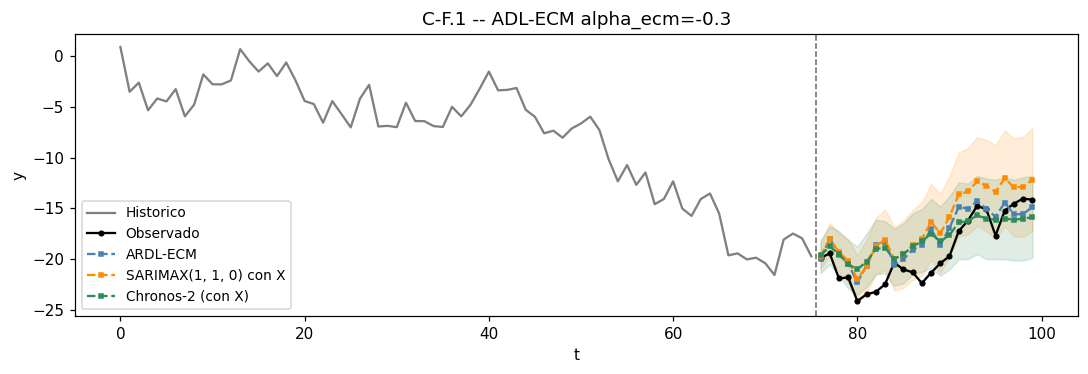

In [19]:
try:
    # C-F.1 -- ADL-ECM alpha_ecm=-0.3
    dgp_C_F_1 = ADL_ECM_DGP(seed=SEED)
    make_models_C_F_1 = lambda T: [
        ARDLModel(),
        SARIMAXModel((1, 1, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_F_1 = dict(alpha_ecm=-0.3, sigma=1.0, sigma_x=1.0)
    verify_dgp_cov("C-F.1 -- ADL-ECM alpha_ecm=-0.3", dgp_C_F_1,
                   dgp_params_C_F_1, CHECKS_ADL_ECM)
    res_C_F_1 = run_exp_cov(
        dgp_C_F_1, make_models_C_F_1, dgp_params_C_F_1,
        exp_id="C-F.1",
    )
    log("\n" + "="*60 + "\nC-F.1 -- ADL-ECM alpha_ecm=-0.3\n" + "="*60)
    build_grid_table(res_C_F_1, classical_name="ARDL-ECM")
    plot_simulation_cov(dgp_C_F_1, make_models_C_F_1(200), dgp_params_C_F_1,
                        title="C-F.1 -- ADL-ECM alpha_ecm=-0.3")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-F.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### C-F.2 — Cointegracion ADL-ECM, correccion rapida (alpha_ecm = -0.6)

**DGP:** mismo sistema con $\alpha_{\text{ecm}} = -0.6$ — la desviacion del equilibrio se corrige el doble de rapido.

**Hipotesis:** la senal de cointegracion es mas fuerte; la ventaja de ARDL-ECM sobre SARIMAX(1,1,0) y Chronos deberia ser aun mayor.


17:31:41  ────────────────────────────────────────────────────────────
17:31:41  VERIFICACION DGP: C-F.2 -- ADL-ECM alpha_ecm=-0.6
17:31:41  ────────────────────────────────────────────────────────────
17:31:42    [PASS] Y es I(1) (ADF niveles/diferencias): ADF Y lvl=0.511, dif=0.000
17:31:42    [PASS] X es I(1) (ADF niveles/diferencias): X0: lvl=0.681, dif=0.000
17:31:42    [PASS] Y - X es I(0) (cointegracion): ADF(Y-X) p=0.0000 (se espera <0.05)
17:31:42    [PASS] ARDL-ECM fit+forecast: ARDL-ECM fit+forecast OK, primeros: [-12.0575 -13.5638 -15.6462]
17:31:42    -> TODAS LAS VERIFICACIONES PASARON
17:31:42  Exp C-F.2: 4 ejecucion(es) -> (T=25, H=6, R=500), (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
17:31:42    T=25 H=6, R=500: cargando exp_C-F_2_T25_R500.csv
17:31:42    T=50 H=18, R=500: cargando exp_C-F_2_T50_R500.csv
17:31:42    T=100 H=24, R=500: cargando exp_C-F_2_T100_R500.csv
17:31:42    T=200 H=24, R=500: cargando exp_C-F_2_T200_R500.csv
17:31:42  
C-F.2 -

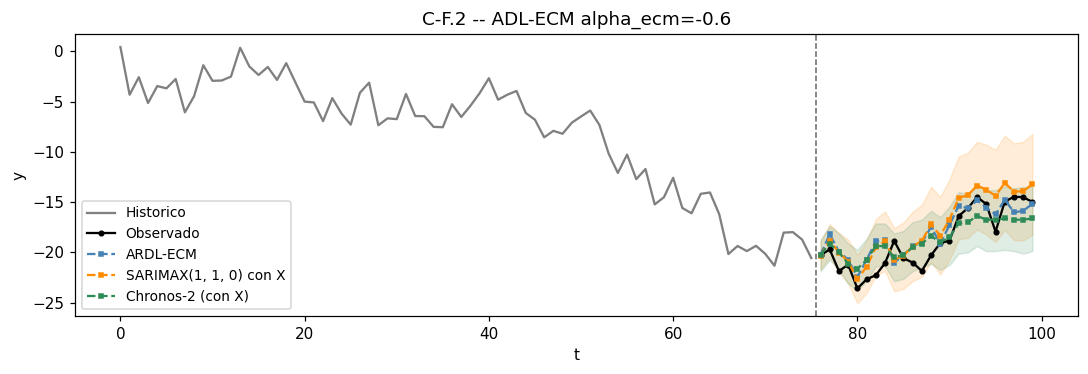

In [20]:
try:
    # C-F.2 -- ADL-ECM alpha_ecm=-0.6
    dgp_C_F_2 = ADL_ECM_DGP(seed=SEED)
    make_models_C_F_2 = lambda T: [
        ARDLModel(),
        SARIMAXModel((1, 1, 0), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_F_2 = dict(alpha_ecm=-0.6, sigma=1.0, sigma_x=1.0)
    verify_dgp_cov("C-F.2 -- ADL-ECM alpha_ecm=-0.6", dgp_C_F_2,
                   dgp_params_C_F_2, CHECKS_ADL_ECM)
    res_C_F_2 = run_exp_cov(
        dgp_C_F_2, make_models_C_F_2, dgp_params_C_F_2,
        exp_id="C-F.2",
    )
    log("\n" + "="*60 + "\nC-F.2 -- ADL-ECM alpha_ecm=-0.6\n" + "="*60)
    build_grid_table(res_C_F_2, classical_name="ARDL-ECM")
    plot_simulation_cov(dgp_C_F_2, make_models_C_F_2(200), dgp_params_C_F_2,
                        title="C-F.2 -- ADL-ECM alpha_ecm=-0.6")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-F.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


---
## Bloque C-G — ARIMAX con tendencia deterministica lineal (3 exps)

Captura series con drift estructural ademas de la dinamica AR y la covariable.
Relevante para macroeconomicas en niveles (PIB, IPC, exportaciones).

**DGP:** $Y_t = \alpha + \delta\,t + \phi\,Y_{t-1}^{stat} + \beta\,X_t + \varepsilon_t$,
con $X_t = \rho_x\,X_{t-1} + \eta_t$. La tendencia se agrega al output final;
la dinamica interna sigue siendo estacionaria (recuperable por SARIMAX con `trend="ct"`).

**Modelo clasico correcto:** `SARIMAXModel(order=(1,0,0), trend="ct", name_suffix="con X+trend")`.
Comparar con SARIMAX sin tendencia ya mostro mejoras de **+44% a +122% en RMSE** —
la misspecificacion de tendencia es muy costosa a horizontes largos.

Variantes:
- **C-G.1**: tendencia leve ($\delta = 0.05$), $\beta = 0.5$.
- **C-G.2**: tendencia fuerte ($\delta = 0.10$), $\beta = 0.5$.
- **C-G.3**: tendencia leve + cov fuerte ($\delta = 0.05$, $\beta = 0.8$).


### C-G.1 — Tendencia leve (delta = 0.05) + cov medio (beta = 0.5)

**DGP:** $Y_t = 0.05\,t + 0.6\,Y_{t-1}^{stat} + 0.5\,X_t + \varepsilon_t$, con $X_t = 0.7\,X_{t-1} + \eta_t$.

**Hipotesis:** SARIMAX con `trend='ct'` captura el drift; Chronos debe inferir la tendencia desde el contexto. Validacion MC mostro que omitir la tendencia (`trend='c'`) cuesta **+44% en RMSE** sobre 24 horizontes.


17:31:44  ────────────────────────────────────────────────────────────
17:31:44  VERIFICACION DGP: C-G.1 -- Tendencia leve delta=0.05
17:31:44  ────────────────────────────────────────────────────────────
17:31:44    [PASS] Y tendencia: slope_OLS ~ delta: slope_OLS=0.04961, delta_DGP=0.05000, tol=0.0100
17:31:44    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
17:31:44    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696], rho_x_DGP=0.7
17:31:44    [PASS] Correlacion Y vs X consistente: corr(Y_detrended,X[0])=0.6533, beta=0.5
17:31:45    [PASS] SARIMAX con X+trend fit+forecast: SARIMAX fit+forecast OK, primeros: [36.6903 37.0726 37.3256]
17:31:45    -> TODAS LAS VERIFICACIONES PASARON
17:31:45  Exp C-G.1: 4 ejecucion(es) -> (T=25, H=6, R=500), (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
17:31:45    T=25 H=6, R=500: cargando exp_C-G_1_T25_R500.csv
17:31:45    T=50 H=18, R=500: cargando exp_C-G_1_T50_R500.csv
17:31:45    T=100 H=24, R=500: cargando exp_C-G_1_T100_R500.csv

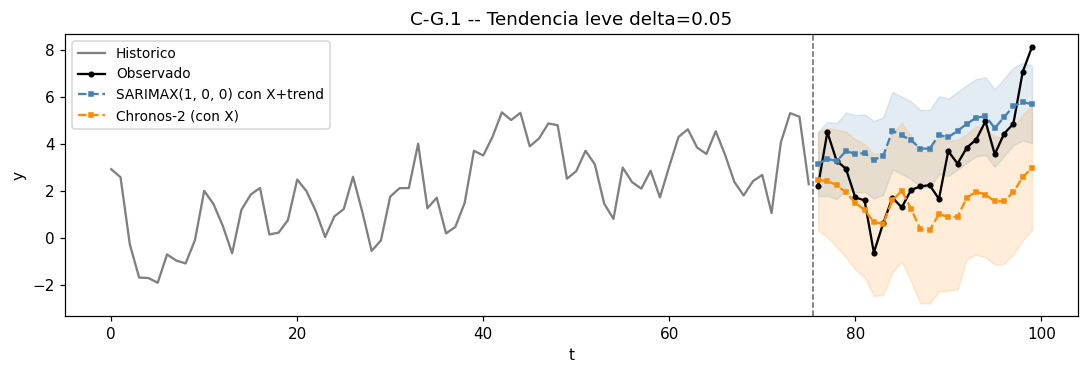

In [21]:
try:
    # C-G.1 -- Tendencia leve delta=0.05
    dgp_C_G_1 = ARIMAX_TREND_DGP(seed=SEED)
    make_models_C_G_1 = lambda T: [
        SARIMAXModel((1, 0, 0), trend='ct', name_suffix='con X+trend'),
        chronos_cov1,
    ]
    dgp_params_C_G_1 = dict(phi=0.6, beta=0.5, alpha=0.0, delta=0.05, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-G.1 -- Tendencia leve delta=0.05", dgp_C_G_1,
                   dgp_params_C_G_1, CHECKS_ARIMAX_TREND)
    res_C_G_1 = run_exp_cov(
        dgp_C_G_1, make_models_C_G_1, dgp_params_C_G_1,
        exp_id="C-G.1",
    )
    log("\n" + "="*60 + "\nC-G.1 -- Tendencia leve delta=0.05\n" + "="*60)
    build_grid_table(res_C_G_1, classical_name="SARIMAX(1, 0, 0) con X+trend",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_G_1, make_models_C_G_1(200),
                        dgp_params_C_G_1,
                        title="C-G.1 -- Tendencia leve delta=0.05")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-G.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### C-G.2 — Tendencia fuerte (delta = 0.10) + cov medio

**DGP:** $\delta = 0.10$ (el doble que C-G.1), $\beta = 0.5$.

**Hipotesis:** drift mas pronunciado — la senal de tendencia domina el forecast. MC mostro que misspecificar tendencia cuesta **+114%** aqui. Mide la capacidad de Chronos de extrapolar trayectorias con pendiente positiva.


17:31:47  ────────────────────────────────────────────────────────────
17:31:47  VERIFICACION DGP: C-G.2 -- Tendencia fuerte delta=0.10
17:31:47  ────────────────────────────────────────────────────────────
17:31:47    [PASS] Y tendencia: slope_OLS ~ delta: slope_OLS=0.09961, delta_DGP=0.10000, tol=0.0200
17:31:47    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
17:31:47    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696], rho_x_DGP=0.7
17:31:47    [PASS] Correlacion Y vs X consistente: corr(Y_detrended,X[0])=0.6533, beta=0.5
17:31:49    [PASS] SARIMAX con X+trend fit+forecast: SARIMAX fit+forecast OK, primeros: [76.7329 77.2071 77.5518]
17:31:49    -> TODAS LAS VERIFICACIONES PASARON
17:31:49  Exp C-G.2: 4 ejecucion(es) -> (T=25, H=6, R=500), (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
17:31:49    T=25 H=6, R=500: cargando exp_C-G_2_T25_R500.csv
17:31:49    T=50 H=18, R=500: cargando exp_C-G_2_T50_R500.csv
17:31:49    T=100 H=24, R=500: cargando exp_C-G_2_T100_R500.c

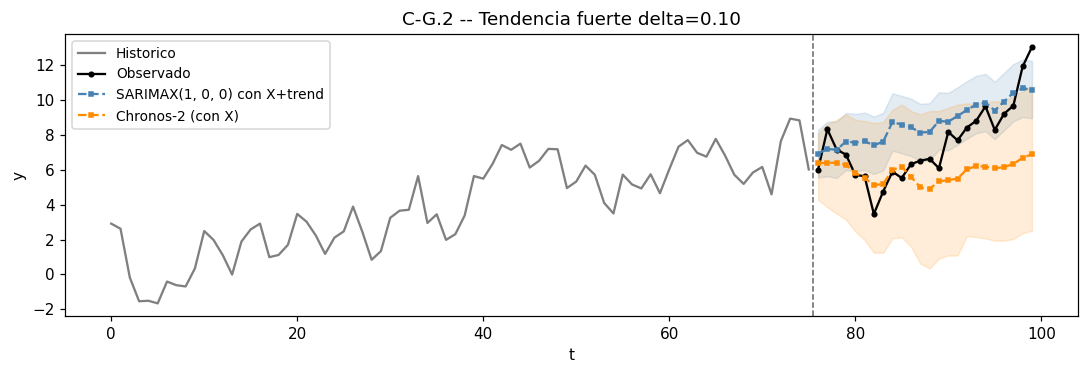

In [22]:
try:
    # C-G.2 -- Tendencia fuerte delta=0.10
    dgp_C_G_2 = ARIMAX_TREND_DGP(seed=SEED)
    make_models_C_G_2 = lambda T: [
        SARIMAXModel((1, 0, 0), trend='ct', name_suffix='con X+trend'),
        chronos_cov1,
    ]
    dgp_params_C_G_2 = dict(phi=0.6, beta=0.5, alpha=0.0, delta=0.10, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-G.2 -- Tendencia fuerte delta=0.10", dgp_C_G_2,
                   dgp_params_C_G_2, CHECKS_ARIMAX_TREND)
    res_C_G_2 = run_exp_cov(
        dgp_C_G_2, make_models_C_G_2, dgp_params_C_G_2,
        exp_id="C-G.2",
    )
    log("\n" + "="*60 + "\nC-G.2 -- Tendencia fuerte delta=0.10\n" + "="*60)
    build_grid_table(res_C_G_2, classical_name="SARIMAX(1, 0, 0) con X+trend",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_G_2, make_models_C_G_2(200),
                        dgp_params_C_G_2,
                        title="C-G.2 -- Tendencia fuerte delta=0.10")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-G.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### C-G.3 — Tendencia leve + cov fuerte (beta = 0.8)

**DGP:** $\delta = 0.05$, $\beta = 0.8$.

**Hipotesis:** combinacion de las dos senales fuertes — tendencia + cov dominante. Compara con C-A.1 ($\beta=0.8$ sin tendencia): la presencia del drift puede cambiar el patron de cruce Chronos vs SARIMAX observado.


17:31:50  ────────────────────────────────────────────────────────────
17:31:50  VERIFICACION DGP: C-G.3 -- Tendencia leve + cov fuerte
17:31:50  ────────────────────────────────────────────────────────────
17:31:50    [PASS] Y tendencia: slope_OLS ~ delta: slope_OLS=0.04942, delta_DGP=0.05000, tol=0.0100
17:31:50    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
17:31:50    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.696], rho_x_DGP=0.7
17:31:50    [PASS] Correlacion Y vs X consistente: corr(Y_detrended,X[0])=0.7695, beta=0.8
17:31:51    [PASS] SARIMAX con X+trend fit+forecast: SARIMAX fit+forecast OK, primeros: [35.8787 36.504  36.9246]
17:31:51    -> TODAS LAS VERIFICACIONES PASARON
17:31:51  Exp C-G.3: 4 ejecucion(es) -> (T=25, H=6, R=500), (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
17:31:51    T=25 H=6, R=500: cargando exp_C-G_3_T25_R500.csv
17:31:51    T=50 H=18, R=500: cargando exp_C-G_3_T50_R500.csv
17:31:51    T=100 H=24, R=500: cargando exp_C-G_3_T100_R500.c

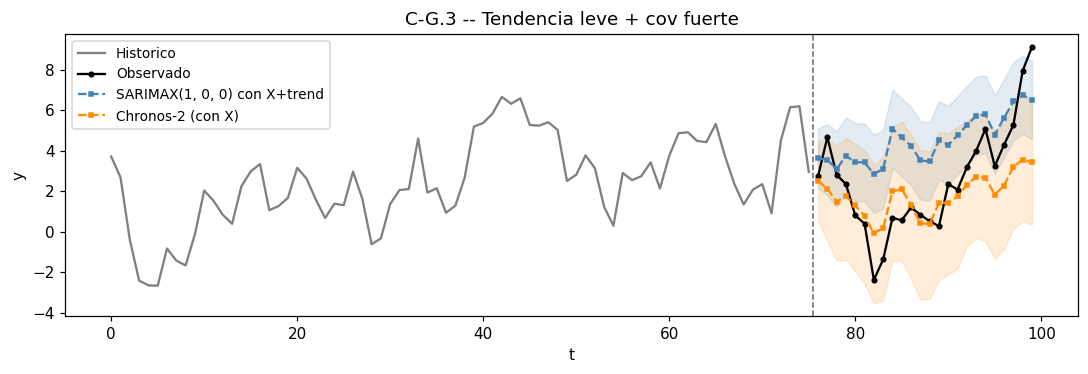

In [23]:
try:
    # C-G.3 -- Tendencia leve + cov fuerte
    dgp_C_G_3 = ARIMAX_TREND_DGP(seed=SEED)
    make_models_C_G_3 = lambda T: [
        SARIMAXModel((1, 0, 0), trend='ct', name_suffix='con X+trend'),
        chronos_cov1,
    ]
    dgp_params_C_G_3 = dict(phi=0.6, beta=0.8, alpha=0.0, delta=0.05, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-G.3 -- Tendencia leve + cov fuerte", dgp_C_G_3,
                   dgp_params_C_G_3, CHECKS_ARIMAX_TREND)
    res_C_G_3 = run_exp_cov(
        dgp_C_G_3, make_models_C_G_3, dgp_params_C_G_3,
        exp_id="C-G.3",
    )
    log("\n" + "="*60 + "\nC-G.3 -- Tendencia leve + cov fuerte\n" + "="*60)
    build_grid_table(res_C_G_3, classical_name="SARIMAX(1, 0, 0) con X+trend",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_G_3, make_models_C_G_3(200),
                        dgp_params_C_G_3,
                        title="C-G.3 -- Tendencia leve + cov fuerte")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-G.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


---
## Bloque C-H — SARIMAX estacional con covariable (4 exps)

Series con componente estacional periodico ademas de AR y covariable.
Relevante para PIB trimestral (s=4) e IPC mensual (s=12).

**DGP:** SARIMA(1,0,0)(1,0,0)[s] con covariable, forma multiplicativa exacta:
$$(1 - \phi L)(1 - \Phi L^s)\,Y_t = \beta\,X_t + \varepsilon_t$$

Expansion: $Y_t = \phi Y_{t-1} + \Phi Y_{t-s} - \phi\Phi Y_{t-s-1} + \beta X_t + \varepsilon_t$.

**Modelo clasico correcto:** `SARIMAXModel(order=(1,0,0), seasonal_order=(1,0,0,s))`.
En MC R=80 a T=200 con $\phi=0.3$, $\Phi=0.7$, el bien especificado gana **+7% a +15%**
sobre SARIMAX sin componente estacional.

Variantes:
- **C-H.1**: trimestral ($s=4$), baseline $\beta = 0.5$.
- **C-H.2**: trimestral ($s=4$), cov fuerte $\beta = 0.8$.
- **C-H.3**: mensual ($s=12$), baseline $\beta = 0.5$. T_list = [50, 100, 200] (T=25 da solo 2 ciclos).
- **C-H.4**: mensual ($s=12$), cov fuerte $\beta = 0.8$. T_list = [50, 100, 200].

Parametros estacionales: $\phi = 0.3$ (AR no estacional debil), $\Phi = 0.7$
(persistencia estacional fuerte), $\rho_x = 0.7$.


### C-H.1 — Estacionalidad trimestral (s=4), cov medio

**DGP:** SARIMA(1,0,0)(1,0,0)[4] multiplicativo: $\phi=0.3$, $\Phi=0.7$, $\beta=0.5$, $\rho_x=0.7$.

**Hipotesis:** SARIMAX con `seasonal_order=(1,0,0,4)` esta correctamente especificado. Chronos debe identificar el ciclo $s=4$ desde el contexto. Validacion MC mostro **+7%** en RMSE para el bien especificado.


17:31:54  ────────────────────────────────────────────────────────────
17:31:54  VERIFICACION DGP: C-H.1 -- Estacional s=4 beta=0.5
17:31:54  ────────────────────────────────────────────────────────────
17:31:54    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
17:31:54    [PASS] Y media ~ 0: media=-0.3903, tol=+/-0.4463 (HAC bw=8, adaptado a s=4)
17:31:54    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
17:31:54    [PASS] ACF[s] estacional significativa: |ACF[s=4](resid)|=0.6757, umbral 2/sqrt(T)=0.0632
17:31:54    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.5174, beta=0.5
17:31:54    [PASS] SARIMAX con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-1.7043 -1.2876 -0.9526]
17:31:54    -> TODAS LAS VERIFICACIONES PASARON
17:31:54  Exp C-H.1: 4 ejecucion(es) -> (T=25, H=6, R=500), (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
17:31:54    T=25 H=6, R=500: cargando exp_C-H_1_T25_R500.csv
17:31:54    T=50 H=18, R=500: cargando exp_C-H_1_T50_R5

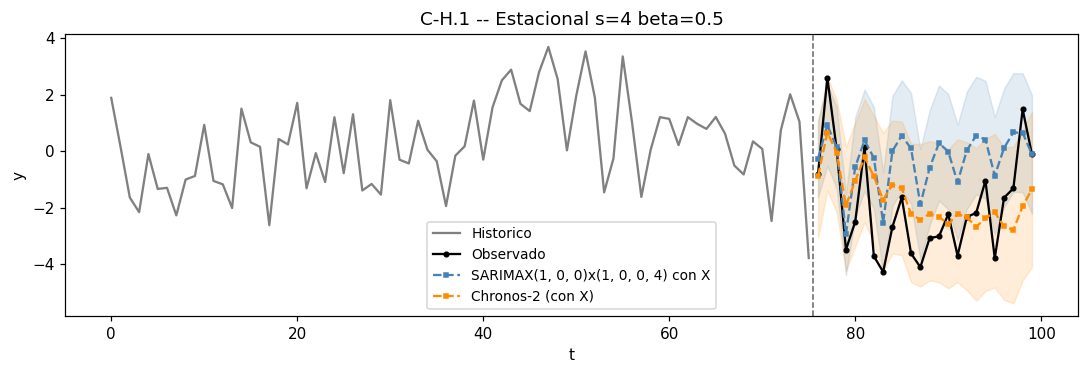

In [24]:
try:
    # C-H.1 -- Estacional s=4 beta=0.5
    dgp_C_H_1 = SARIMAX_SEASONAL_DGP(seed=SEED)
    make_models_C_H_1 = lambda T: [
        SARIMAXModel((1, 0, 0), seasonal_order=(1, 0, 0, 4), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_H_1 = dict(s=4, phi=0.3, Phi=0.7, beta=0.5, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-H.1 -- Estacional s=4 beta=0.5", dgp_C_H_1,
                   dgp_params_C_H_1, CHECKS_ARIMAX_SEASONAL)
    res_C_H_1 = run_exp_cov(
        dgp_C_H_1, make_models_C_H_1, dgp_params_C_H_1,
        exp_id="C-H.1",
    )
    log("\n" + "="*60 + "\nC-H.1 -- Estacional s=4 beta=0.5\n" + "="*60)
    build_grid_table(res_C_H_1, classical_name="SARIMAX(1, 0, 0)x(1, 0, 0, 4) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_H_1, make_models_C_H_1(200),
                        dgp_params_C_H_1,
                        title="C-H.1 -- Estacional s=4 beta=0.5")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-H.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### C-H.2 — Estacionalidad trimestral (s=4), cov fuerte (beta = 0.8)

**DGP:** identico a C-H.1 pero $\beta = 0.8$.

**Hipotesis:** la combinacion de estacionalidad fuerte ($\Phi=0.7$) + cov fuerte testea si Chronos puede aprovechar ambas senales simultaneamente con muestra larga (T=200), como en C-A.1.


17:31:56  ────────────────────────────────────────────────────────────
17:31:56  VERIFICACION DGP: C-H.2 -- Estacional s=4 beta=0.8
17:31:56  ────────────────────────────────────────────────────────────
17:31:56    [PASS] Y estacionaria (ADF): ADF Y p=0.0000 (umbral 0.05)
17:31:56    [PASS] Y media ~ 0: media=-0.5112, tol=+/-0.6580 (HAC bw=8, adaptado a s=4)
17:31:56    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
17:31:56    [PASS] ACF[s] estacional significativa: |ACF[s=4](resid)|=0.6852, umbral 2/sqrt(T)=0.0632
17:31:56    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.5999, beta=0.8
17:31:56    [PASS] SARIMAX con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-1.6839 -1.2157 -0.8758]
17:31:56    -> TODAS LAS VERIFICACIONES PASARON
17:31:56  Exp C-H.2: 4 ejecucion(es) -> (T=25, H=6, R=500), (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
17:31:56    T=25 H=6, R=500: cargando exp_C-H_2_T25_R500.csv
17:31:56    T=50 H=18, R=500: cargando exp_C-H_2_T50_R5

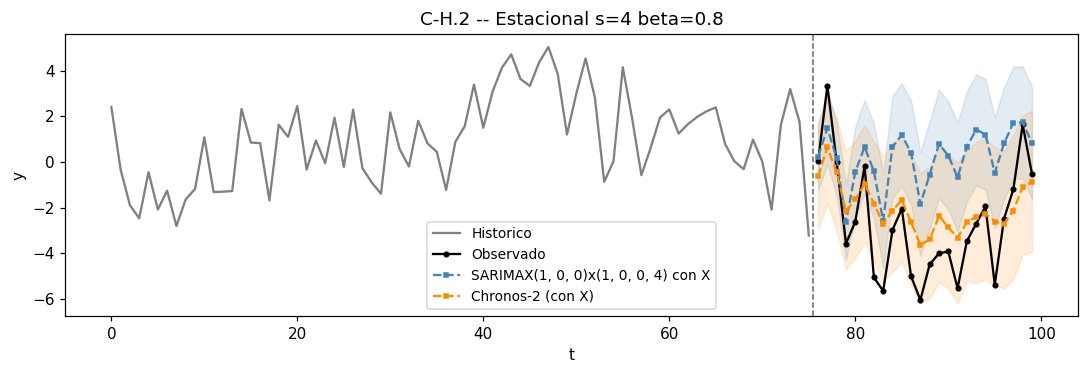

In [25]:
try:
    # C-H.2 -- Estacional s=4 beta=0.8
    dgp_C_H_2 = SARIMAX_SEASONAL_DGP(seed=SEED)
    make_models_C_H_2 = lambda T: [
        SARIMAXModel((1, 0, 0), seasonal_order=(1, 0, 0, 4), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_H_2 = dict(s=4, phi=0.3, Phi=0.7, beta=0.8, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-H.2 -- Estacional s=4 beta=0.8", dgp_C_H_2,
                   dgp_params_C_H_2, CHECKS_ARIMAX_SEASONAL)
    res_C_H_2 = run_exp_cov(
        dgp_C_H_2, make_models_C_H_2, dgp_params_C_H_2,
        exp_id="C-H.2",
    )
    log("\n" + "="*60 + "\nC-H.2 -- Estacional s=4 beta=0.8\n" + "="*60)
    build_grid_table(res_C_H_2, classical_name="SARIMAX(1, 0, 0)x(1, 0, 0, 4) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_H_2, make_models_C_H_2(200),
                        dgp_params_C_H_2,
                        title="C-H.2 -- Estacional s=4 beta=0.8")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-H.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### C-H.3 — Estacionalidad mensual (s=12), cov medio

**DGP:** SARIMA(1,0,0)(1,0,0)[12] multiplicativo. **T_list restringido a [50, 100, 200]** (T=25 da solo ~2 ciclos estacionales, insuficiente para identificar $\Phi$).

**Hipotesis:** estacionalidad de baja frecuencia con muchos parametros efectivos. Modelos estacionales tipicamente necesitan T >> 2s para estimacion confiable.


17:31:58  ────────────────────────────────────────────────────────────
17:31:58  VERIFICACION DGP: C-H.3 -- Estacional s=12 beta=0.5
17:31:58  ────────────────────────────────────────────────────────────
17:31:59    [PASS] Y estacionaria (ADF): ADF Y p=0.0044 (umbral 0.05)
17:31:59    [PASS] Y media ~ 0: media=-0.3684, tol=+/-0.4217 (HAC bw=24, adaptado a s=12)
17:31:59    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
17:31:59    [PASS] ACF[s] estacional significativa: |ACF[s=12](resid)|=0.6795, umbral 2/sqrt(T)=0.0632
17:31:59    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.4473, beta=0.5
17:31:59    [PASS] SARIMAX con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-1.6189 -1.2607 -0.9473]
17:31:59    -> TODAS LAS VERIFICACIONES PASARON
17:31:59  Exp C-H.3: 3 ejecucion(es) -> (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
17:31:59    T=50 H=18, R=500: cargando exp_C-H_3_T50_R500.csv
17:31:59    T=100 H=24, R=500: cargando exp_C-H_3_T100_R500.csv
17:31:

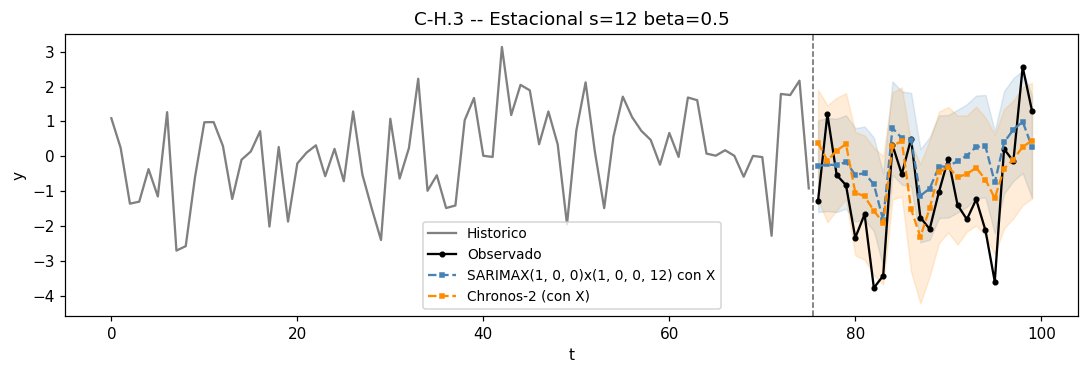

In [26]:
try:
    # C-H.3 -- Estacional s=12 beta=0.5
    dgp_C_H_3 = SARIMAX_SEASONAL_DGP(seed=SEED)
    make_models_C_H_3 = lambda T: [
        SARIMAXModel((1, 0, 0), seasonal_order=(1, 0, 0, 12), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_H_3 = dict(s=12, phi=0.3, Phi=0.7, beta=0.5, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-H.3 -- Estacional s=12 beta=0.5", dgp_C_H_3,
                   dgp_params_C_H_3, CHECKS_ARIMAX_SEASONAL)
    res_C_H_3 = run_exp_cov(
        dgp_C_H_3, make_models_C_H_3, dgp_params_C_H_3,
        exp_id="C-H.3",
        T_list=[50, 100, 200],
    )
    log("\n" + "="*60 + "\nC-H.3 -- Estacional s=12 beta=0.5\n" + "="*60)
    build_grid_table(res_C_H_3, classical_name="SARIMAX(1, 0, 0)x(1, 0, 0, 12) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_H_3, make_models_C_H_3(200),
                        dgp_params_C_H_3,
                        title="C-H.3 -- Estacional s=12 beta=0.5")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-H.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### C-H.4 — Estacionalidad mensual (s=12), cov fuerte (beta = 0.8)

**DGP:** identico a C-H.3 pero $\beta = 0.8$. Mismo T_list restringido.

**Hipotesis:** cov fuerte combinada con estacionalidad de baja frecuencia — el caso mas exigente del bloque. Verifica si Chronos extrae beneficio de la cov cuando la senal estacional es periodica y larga.


17:32:00  ────────────────────────────────────────────────────────────
17:32:00  VERIFICACION DGP: C-H.4 -- Estacional s=12 beta=0.8
17:32:00  ────────────────────────────────────────────────────────────
17:32:01    [PASS] Y estacionaria (ADF): ADF Y p=0.0037 (umbral 0.05)
17:32:01    [PASS] Y media ~ 0: media=-0.4798, tol=+/-0.6140 (HAC bw=24, adaptado a s=12)
17:32:01    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
17:32:01    [PASS] ACF[s] estacional significativa: |ACF[s=12](resid)|=0.6877, umbral 2/sqrt(T)=0.0632
17:32:01    [PASS] Correlacion Y vs X consistente: corr(Y,X[0])=0.5578, beta=0.8
17:32:01    [PASS] SARIMAX con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-2.5079 -1.8427 -1.3351]
17:32:01    -> TODAS LAS VERIFICACIONES PASARON
17:32:01  Exp C-H.4: 3 ejecucion(es) -> (T=50, H=18, R=500), (T=100, H=24, R=500), (T=200, H=24, R=500)
17:32:01    T=50 H=18, R=500: cargando exp_C-H_4_T50_R500.csv
17:32:01    T=100 H=24, R=500: cargando exp_C-H_4_T100_R500.csv
17:32:

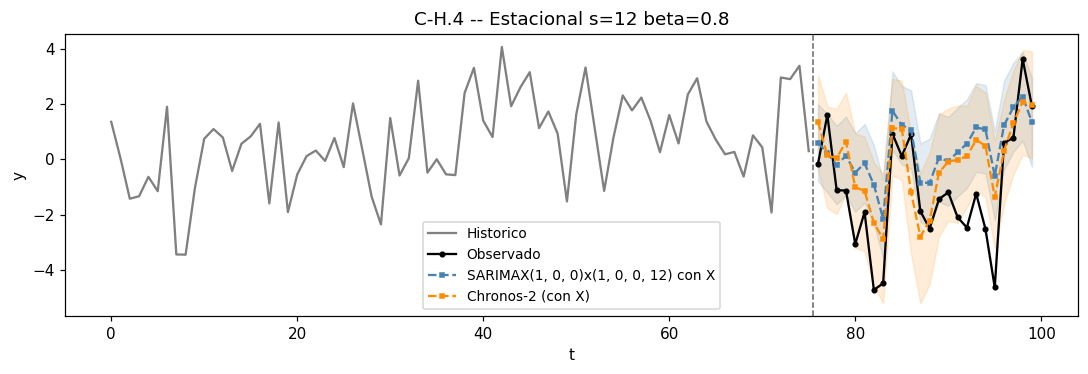

In [27]:
try:
    # C-H.4 -- Estacional s=12 beta=0.8
    dgp_C_H_4 = SARIMAX_SEASONAL_DGP(seed=SEED)
    make_models_C_H_4 = lambda T: [
        SARIMAXModel((1, 0, 0), seasonal_order=(1, 0, 0, 12), name_suffix='con X'),
        chronos_cov1,
    ]
    dgp_params_C_H_4 = dict(s=12, phi=0.3, Phi=0.7, beta=0.8, sigma_y=1.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-H.4 -- Estacional s=12 beta=0.8", dgp_C_H_4,
                   dgp_params_C_H_4, CHECKS_ARIMAX_SEASONAL)
    res_C_H_4 = run_exp_cov(
        dgp_C_H_4, make_models_C_H_4, dgp_params_C_H_4,
        exp_id="C-H.4",
        T_list=[50, 100, 200],
    )
    log("\n" + "="*60 + "\nC-H.4 -- Estacional s=12 beta=0.8\n" + "="*60)
    build_grid_table(res_C_H_4, classical_name="SARIMAX(1, 0, 0)x(1, 0, 0, 12) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_H_4, make_models_C_H_4(200),
                        dgp_params_C_H_4,
                        title="C-H.4 -- Estacional s=12 beta=0.8")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-H.4 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


---
## Resumen

25 experimentos x 4 valores de T x 1 R = 98 corridas Monte Carlo (R=500 cada una;
C-H.3/4 corren solo 3 T cada uno => 8 corridas en vez de 16).
Tiempo estimado: ~4-7 h en CPU (Vertex AI free tier), considerablemente menor en GPU.

**Cobertura de la grilla:**

| Bloque | Experimentos | Variacion principal                  |
|--------|--------------|--------------------------------------|
| C-A    | 5            | beta (0.2/0.5/0.8), rho_x (0/0.7/0.95)|
| C-B    | 2            | phi (0.9 / -0.6) — dinamica AR rica  |
| C-C    | 3            | n_covariables y configuracion        |
| C-D    | 3            | canal (media / varianza / ambos)     |
| C-E    | 3            | gamma y matriz A (multivariado)      |
| C-F    | 2            | alpha_ecm (cointegracion)            |
| C-G    | 3            | delta (tendencia deterministica)     |
| C-H    | 4            | s (4 / 12), beta (0.5 / 0.8) estacional |

**Output:**
- CSV por experimento en `results/covariate_vertexai/exp_*.csv`
- Log de ejecucion en `results/covariate_vertexai/run_*.log`

**Para re-ejecutar:** borrar el CSV correspondiente y volver a correr la celda. Los demas se cargaran desde cache.
